# Configuration Comparison

This notebook documents the fixed-split configuration study used to compare PPO reward functions, policy networks, and training-stability settings on the processed Dow 30 panel.

## 1. Data Loading

In [2]:
## install finrl library
#!pip install wrds
#!pip install swig
#!pip install -q condacolab
#import condacolab
#condacolab.install()
#!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-y9wwywvz
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-y9wwywvz
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-u94twwv0/elegantrl_53ccd669df884e0fa75f625505633828
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-u94twwv0/elegantrl_53ccd669df884e0fa75f625505633828
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 24228304867bdc80165de435a598ef90b1893598
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import torch
# import torch.nn as nn
# import torch.optim as optim

from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent, DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from stable_baselines3 import PPO, A2C, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv

from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

%matplotlib inline

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
C:\Users\ivanp\anaconda3\envs\tensorflow\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [2]:
processed = pd.read_csv('processed_final_fixed.csv', index_col=0, parse_dates=['date', 'date_available'])

## 2. Feature Screening and Final State-Space Design

This section narrows the candidate feature set through correlation analysis, Random Forest importance, PCA loadings, and VIF diagnostics before defining the final RL state space.

### 2.1 Correlation, VIF, and Feature-Importance Diagnostics

In [3]:
processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96019 entries, 0 to 96018
Data columns (total 79 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    96019 non-null  datetime64[ns]
 1   close                   96019 non-null  float64       
 2   high                    96019 non-null  float64       
 3   low                     96019 non-null  float64       
 4   open                    96019 non-null  float64       
 5   volume                  96019 non-null  int64         
 6   day                     96019 non-null  int64         
 7   date_available          96019 non-null  datetime64[ns]
 8   op_inc_q                96019 non-null  float64       
 9   rev_q                   96019 non-null  float64       
 10  net_inc_q               96019 non-null  float64       
 11  tot_assets              96019 non-null  float64       
 12  sh_equity               96019 non-null  float64    

In [ ]:
processed['tic'].unique()

array(['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX',
       'DIS', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD',
       'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT'],
      dtype=object)

In [ ]:
# Analyze correlation with the target variable (for example, future_return)
correlations = []
analysis_df = processed.sort_values(['tic', 'date']).copy()
target = analysis_df.groupby('tic')['close'].pct_change().shift(-1)  # next-day return for each ticker

for col in analysis_df.select_dtypes(include=[np.number]).columns:
    if col != 'close':
        corr = analysis_df[col].corr(target)
        correlations.append((col, abs(corr)))

correlations.sort(key=lambda x: x[1], reverse=True)
print("Топ признаков по корреляции с будущей доходностью:")
for col, corr in correlations:
    print(f"{col}: {corr:.4f}")


Топ признаков по корреляции с будущей доходностью:
forecast_trend: 0.1570
gru_return_forecast_5d: 0.1534
gru_return_forecast_3d: 0.1519
gru_return_forecast_4d: 0.1511
forecast_mean: 0.1501
gru_return_forecast_2d: 0.1417
gru_return_forecast_1d: 0.1281
daily_return: 0.0561
SP500_Trend: 0.0417
VIX: 0.0358
atr_rel: 0.0336
rsi_30: 0.0265
forecast_std: 0.0251
macd: 0.0248
10Y_Yield: 0.0186
cci_30: 0.0174
day: 0.0168
open: 0.0133
low: 0.0133
high: 0.0133
day_cos: 0.0124
PE_ratio: 0.0108
volume_ratio: 0.0107
turbulence: 0.0103
enterprise_value: 0.0092
market_cap: 0.0081
PB_ratio: 0.0076
dividend_yield: 0.0074
EV_EBITDA: 0.0072
dx_30: 0.0064
day_sin: 0.0050
PS_ratio: 0.0048
volume: 0.0039
cur_assets: 0.0038
cash_ratio: 0.0035
eps_incl_ex: 0.0034
EPS: 0.0034
sh_outstanding: 0.0034
obv_pct_change: 0.0031
cur_ratio: 0.0027
quick_ratio: 0.0026
inventories: 0.0025
ROE: 0.0024
div_per_sh: 0.0024
DPS: 0.0024
long_debt: 0.0023
short_debt: 0.0022
Market_Regime: 0.0020
debt_ratio: 0.0020
NPM: 0.0016
inv_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
TOP_CORRELATED_FEATURES = [
    # 1. GRU forecasts
    'forecast_trend',
    'gru_return_forecast_4d',
    'gru_return_forecast_5d',
    'forecast_mean',
    'gru_return_forecast_3d',
    'gru_return_forecast_2d',
    'gru_return_forecast_1d',
    'forecast_std',

    # 2. Price data and returns
    'daily_return',
    'open',
    'low',
    'high',

    # 3. Macroeconomic indicators
    '10Y_Yield',
    'SP500_Trend',
    'VIX',

    # 4. Market regimes (HMM)
    'Regime_0_Prob',
    'Regime_1_Prob',
    'Market_Regime',

    # 5. Technical indicators
    'atr_rel',
    'rsi_30',
    'macd',
    'atr',
    'dx_30',
    'cci_30',

    # 6. Fundamental metrics (firm valuation)
    'PE_ratio',
    'PB_ratio',
    'PS_ratio',
    'EV_EBITDA',

    # 7. Firm size
    'enterprise_value',
    'market_cap',
    'sh_outstanding',

    # 8. Dividend metrics
    'dividend_yield',
    'div_per_sh',
    'DPS',

    # 9. Risk and leverage metrics
    'debt_ratio',
    'turbulence',
    'long_debt',
    'short_debt',

    # 10. Efficiency and profitability metrics
    'net_inc_q',
    'revenue_growth',
    'op_inc_q',
    'ROE',
    'EPS',
    'eps_incl_ex',
    'NPM',

    # 11. Liquidity metrics
    'cur_ratio',
    'cash_ratio',
    'quick_ratio',

    # 12. Volume-based metrics
    'volume_ratio',
    'volume',
    'obv_pct_change',

    # 13. Time features (seasonality)
    'day_sin',
    'day',
    'day_cos',

    # 14. Operating activity metrics
    'acc_pay_turnover',
    'acc_rec_turnover',

    # 15. Balance-sheet metrics
    'tot_liabilities',
    'tot_assets',
    'inventories',
    'payables',
    'receivables',
    'cash_eq',
    'sh_equity',

    # 16. Other metrics
    'rev_q',
    'eps_growth',
    'OPM',
    'inv_turnover',
    'BPS',
    'ROA',
    'cogs_q',
]

In [ ]:
print(f"Отобранных признаков: {len(TOP_CORRELATED_FEATURES)}")
# Create a DataFrame with the selected features
features_df = processed[TOP_CORRELATED_FEATURES].dropna()

Отобранных признаков: 70


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_feature_reduction(data, features, n_components=0.95):
    """
    Dimensionality reduction with PCA
    """
    df = data[features].copy().fillna(method='ffill')

    # Standardization
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # PCA
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(scaled_data)

    print(f"PCA результаты:")
    print(f"Оригинальные признаки: {len(features)}")
    print(f"PCA компоненты: {pca.n_components_}")
    print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

    # Feature importance for each component
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=features
    )

    print("\nТоп признаков по важности в первой компоненте:")
    print(loadings['PC1'].abs().sort_values(ascending=False))
    print("\nТоп признаков по важности в второй компоненте:")
    print(loadings['PC2'].abs().sort_values(ascending=False))
    return pca_data, loadings

# If VIF indicates high multicollinearity
pca_features, loadings = pca_feature_reduction(
    processed,
    TOP_CORRELATED_FEATURES,
    n_components=0.95  # explain 95% of the variance
)

/tmp/ipykernel_1167/2211732497.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = data[features].copy().fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PCA результаты:
Оригинальные признаки: 70
PCA компоненты: 31
Объясненная дисперсия: 0.952

Топ признаков по важности в первой компоненте:
long_debt                 0.297496
cash_eq                   0.293456
tot_assets                0.293091
tot_liabilities           0.290776
receivables               0.283170
payables                  0.272242
short_debt                0.270721
sh_equity                 0.237344
op_inc_q                  0.216404
net_inc_q                 0.173198
BPS                       0.169037
acc_pay_turnover          0.163484
inventories               0.137976
enterprise_value          0.132828
atr                       0.128945
market_cap                0.126769
high                      0.116200
open                      0.115811
low                       0.115483
debt_ratio                0.114491
PS_ratio                  0.106267
OPM                       0.095321
eps_incl_ex               0.092034
EPS                       0.092034
sh_outstanding        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def feature_importance_analysis(data, features, target='close'):
    """Feature importance analysis."""
    data = data.sort_values(['tic', 'date']).copy()

    # Data preparation
    X = data[features].copy()
    X = X.groupby(data['tic']).ffill()
    y = data.groupby('tic')[target].pct_change().shift(-1)  # future return for each ticker

    # Alignment
    aligned_idx = X.index.intersection(y.dropna().index)
    X = X.loc[aligned_idx]
    y = y.loc[aligned_idx]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    # Training
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Feature importance
    importance = pd.DataFrame({
        'feature': features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Топ-15 важных признаков по RandomForest:")
    print(importance.head(15).to_string())

    return importance

# Analysis
importance_df = feature_importance_analysis(processed, TOP_CORRELATED_FEATURES)

# Select features using an importance threshold
threshold = 0.01  # 1%
selected_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()
print(f"\nПризнаки с важностью >{threshold}: {len(selected_features)}")
print(selected_features)


Топ-15 важных признаков по RandomForest:
           feature  importance
13     SP500_Trend    0.064171
14             VIX    0.057042
12       10Y_Yield    0.054242
35      turbulence    0.053268
8     daily_return    0.052222
48    volume_ratio    0.042452
18         atr_rel    0.039997
20            macd    0.030598
50  obv_pct_change    0.029224
22           dx_30    0.029113
23          cci_30    0.028877
16   Regime_1_Prob    0.026748
19          rsi_30    0.026096
49          volume    0.024836
21             atr    0.019781

Признаки с важностью >0.01: 32
['SP500_Trend', 'VIX', '10Y_Yield', 'turbulence', 'daily_return', 'volume_ratio', 'atr_rel', 'macd', 'obv_pct_change', 'dx_30', 'cci_30', 'Regime_1_Prob', 'rsi_30', 'volume', 'atr', 'forecast_trend', 'PE_ratio', 'gru_return_forecast_5d', 'EV_EBITDA', 'market_cap', 'PS_ratio', 'gru_return_forecast_4d', 'enterprise_value', 'day_sin', 'forecast_std', 'PB_ratio', 'dividend_yield', 'gru_return_forecast_1d', 'gru_return_forecast_3d',

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
importance_df


,feature,importance
13,SP500_Trend,0.064171
14,VIX,0.057042
12,10Y_Yield,0.054242
35,turbulence,0.053268
8,daily_return,0.052222
48,volume_ratio,0.042452
18,atr_rel,0.039997
20,macd,0.030598
50,obv_pct_change,0.029224
22,dx_30,0.029113


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 2.2 Visualization Diagnostics

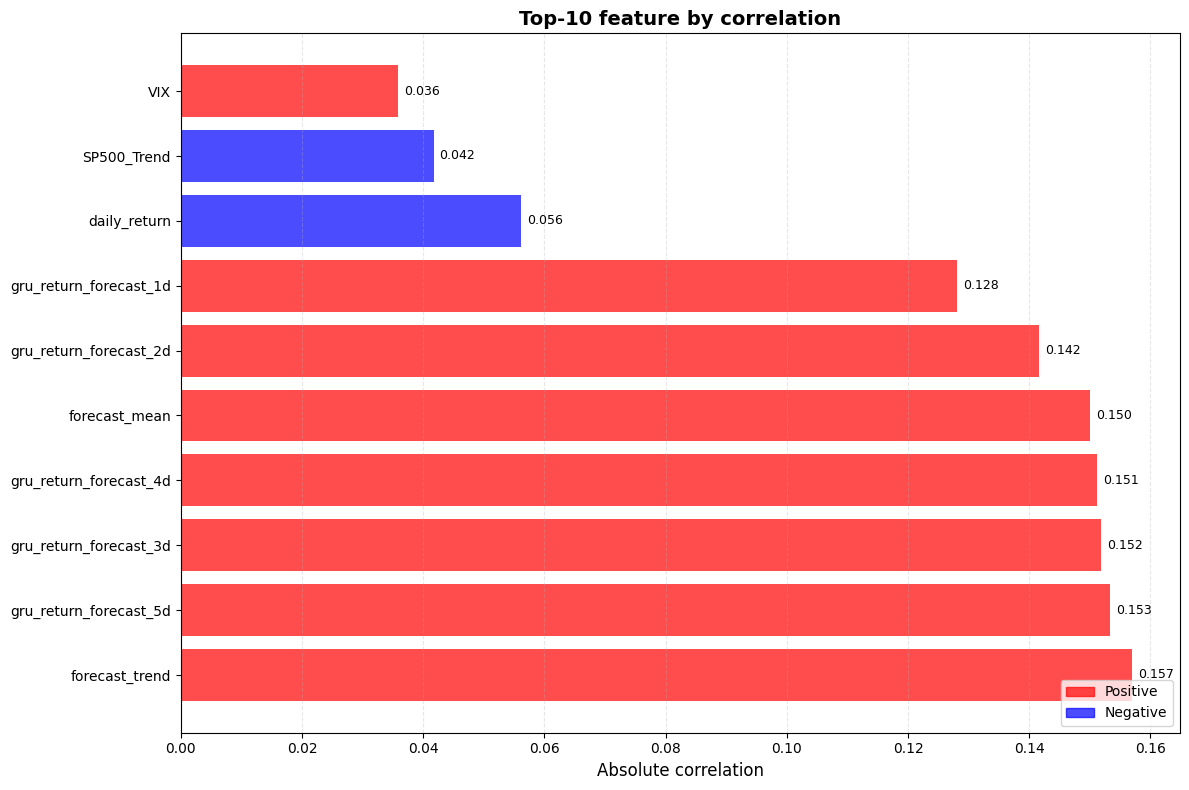

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_correlation_results(correlations, top_n=20):
    """
    Plot of feature correlations with the target variable
    """
    # Take the top-N features
    top_corr = correlations[:top_n]
    features, corr_values = zip(*top_corr)

    # Create a color scheme (red for positive, blue for negative correlation)
    colors = ['red' if processed[feat].corr(target) > 0 else 'blue'
              for feat in features]

    fig, ax = plt.subplots(figsize=(12, 8))

    # Horizontal bar plot
    bars = ax.barh(features, corr_values, color=colors, alpha=0.7)
    ax.set_xlabel('Absolute correlation', fontsize=12)
    ax.set_title(f'Top-{top_n} feature by correlation',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add values to the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    # Zero-correlation line
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

    # Legend
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='red', alpha=0.7, label='Positive')
    blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='Negative')
    ax.legend(handles=[red_patch, blue_patch], loc='lower right')

    plt.tight_layout()
    return fig

# Usage
fig1 = plot_correlation_results(correlations, top_n=10)
plt.show()

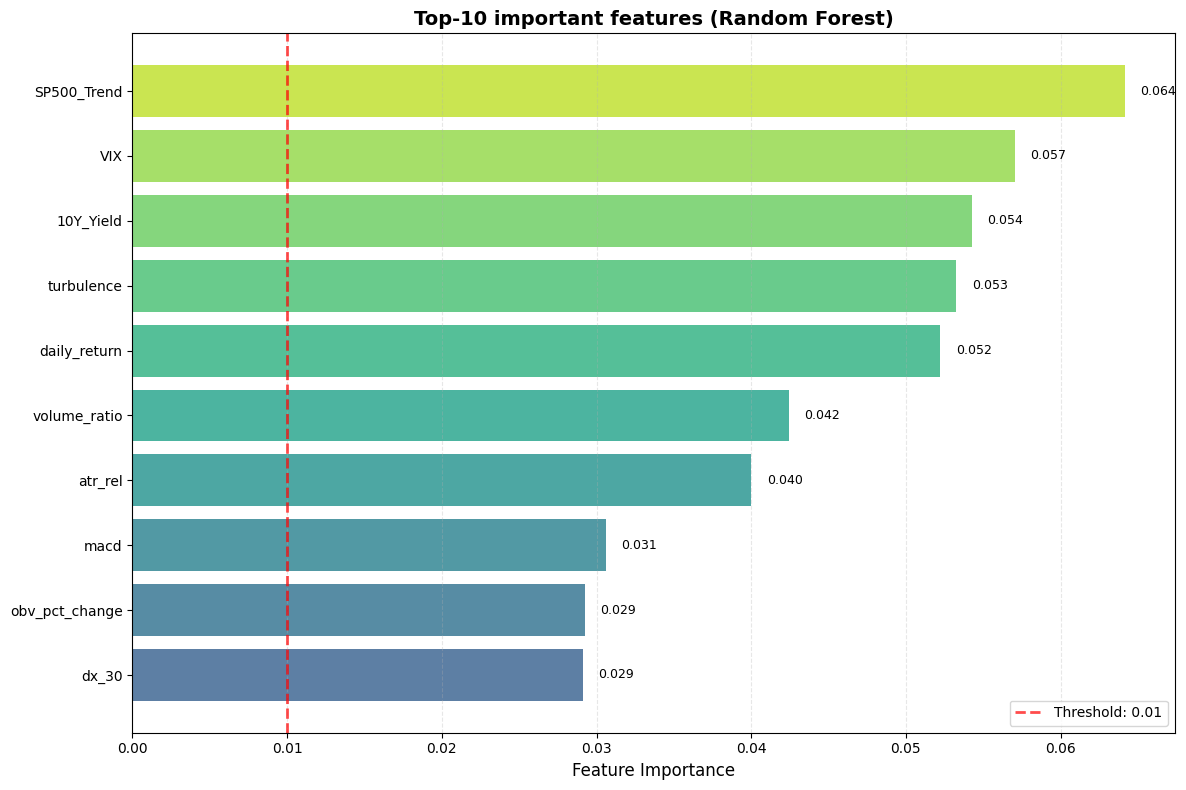

In [ ]:
def plot_feature_importance(importance_df, top_n=20, threshold=None):
    """
    Plot of feature importance from Random Forest
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Take the top-N features
    top_features = importance_df.head(top_n).copy()

    # Sort for the horizontal chart
    top_features = top_features.sort_values('importance', ascending=True)

    # Create a color gradient
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

    # Horizontal bar plot
    bars = ax.barh(top_features['feature'], top_features['importance'],
                   color=colors, alpha=0.8)

    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top-{top_n} important features (Random Forest)',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add the threshold line if one is provided
    if threshold:
        ax.axvline(x=threshold, color='red', linestyle='--',
                   linewidth=2, alpha=0.7, label=f'Threshold: {threshold}')
        ax.legend()

    # Add values to the bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    return fig

# Usage
fig2 = plot_feature_importance(importance_df, top_n=10, threshold=0.01)
plt.show()

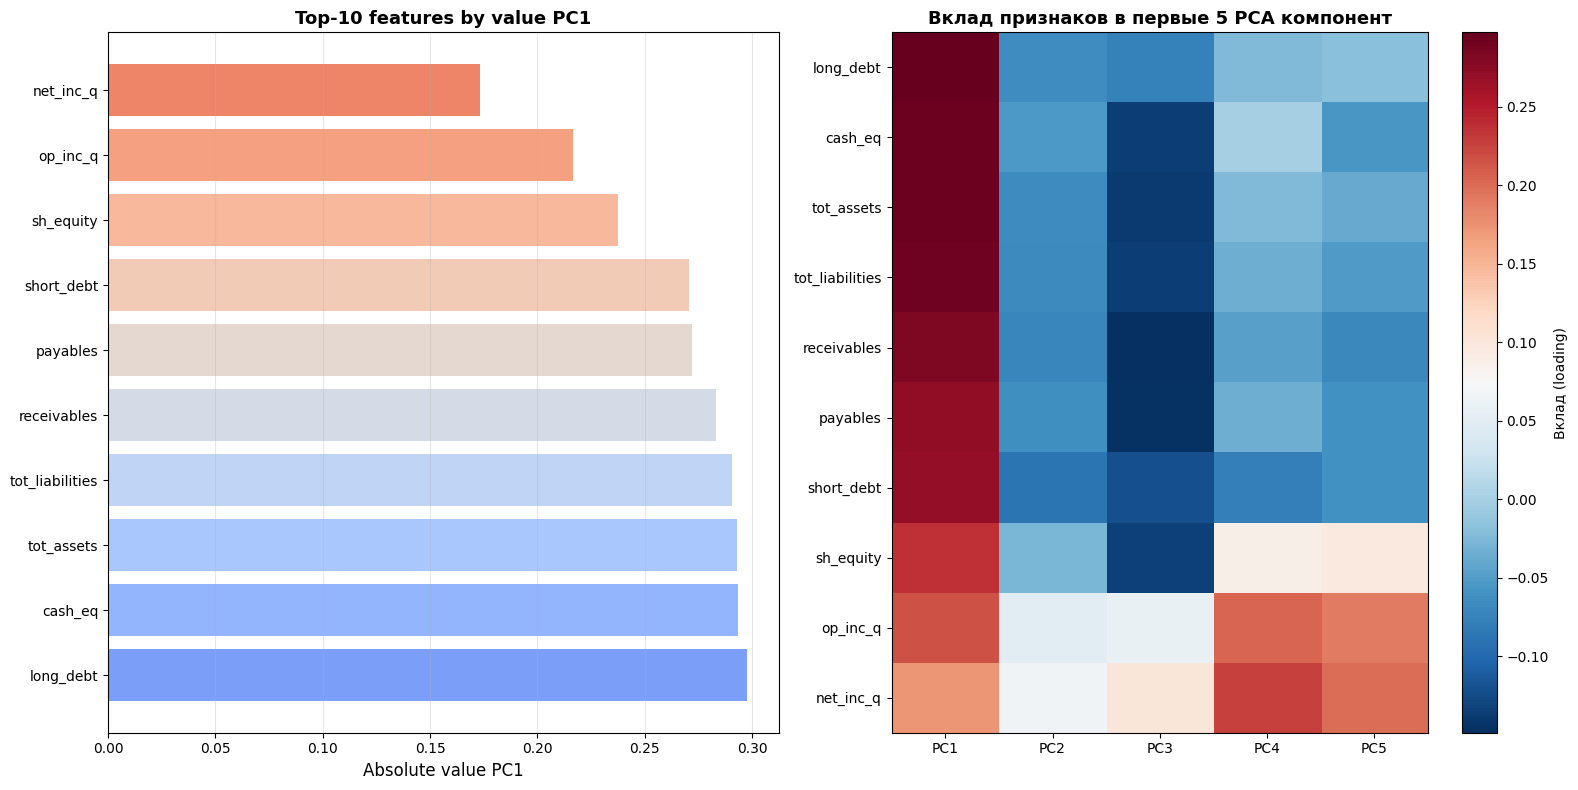

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def plot_pca_loadings(loadings, top_n=15):
    """
    Plot of feature contributions to the main PCA components
    """
    # Take the top-N features by the first component
    top_loadings = loadings['PC1'].abs().sort_values(ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot 1: Contribution to the first component
    colors1 = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top_loadings)))
    bars1 = axes[0].barh(top_loadings.index, top_loadings.values, color=colors1)
    axes[0].set_xlabel('Absolute value PC1', fontsize=12)
    axes[0].set_title(f'Top-{top_n} features by value PC1',
                     fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # Plot 2: Heatmap of contributions to the first 5 components
    # Take the top-10 features by PC1 and inspect their contributions to the first 5 components
    top_features = top_loadings.index[:10]
    component_loadings = loadings.loc[top_features, ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]

    # Heatmap
    im = axes[1].imshow(component_loadings.values, cmap='RdBu_r', aspect='auto')
    axes[1].set_xticks(range(5))
    axes[1].set_xticklabels(['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
    axes[1].set_yticks(range(len(top_features)))
    axes[1].set_yticklabels(top_features)
    axes[1].set_title('Вклад признаков в первые 5 PCA компонент',
                     fontsize=13, fontweight='bold')

    # Color scale
    plt.colorbar(im, ax=axes[1], label='Вклад (loading)')

    plt.tight_layout()
    return fig

# Usage
fig3 = plot_pca_loadings(loadings, top_n=10)
plt.show()

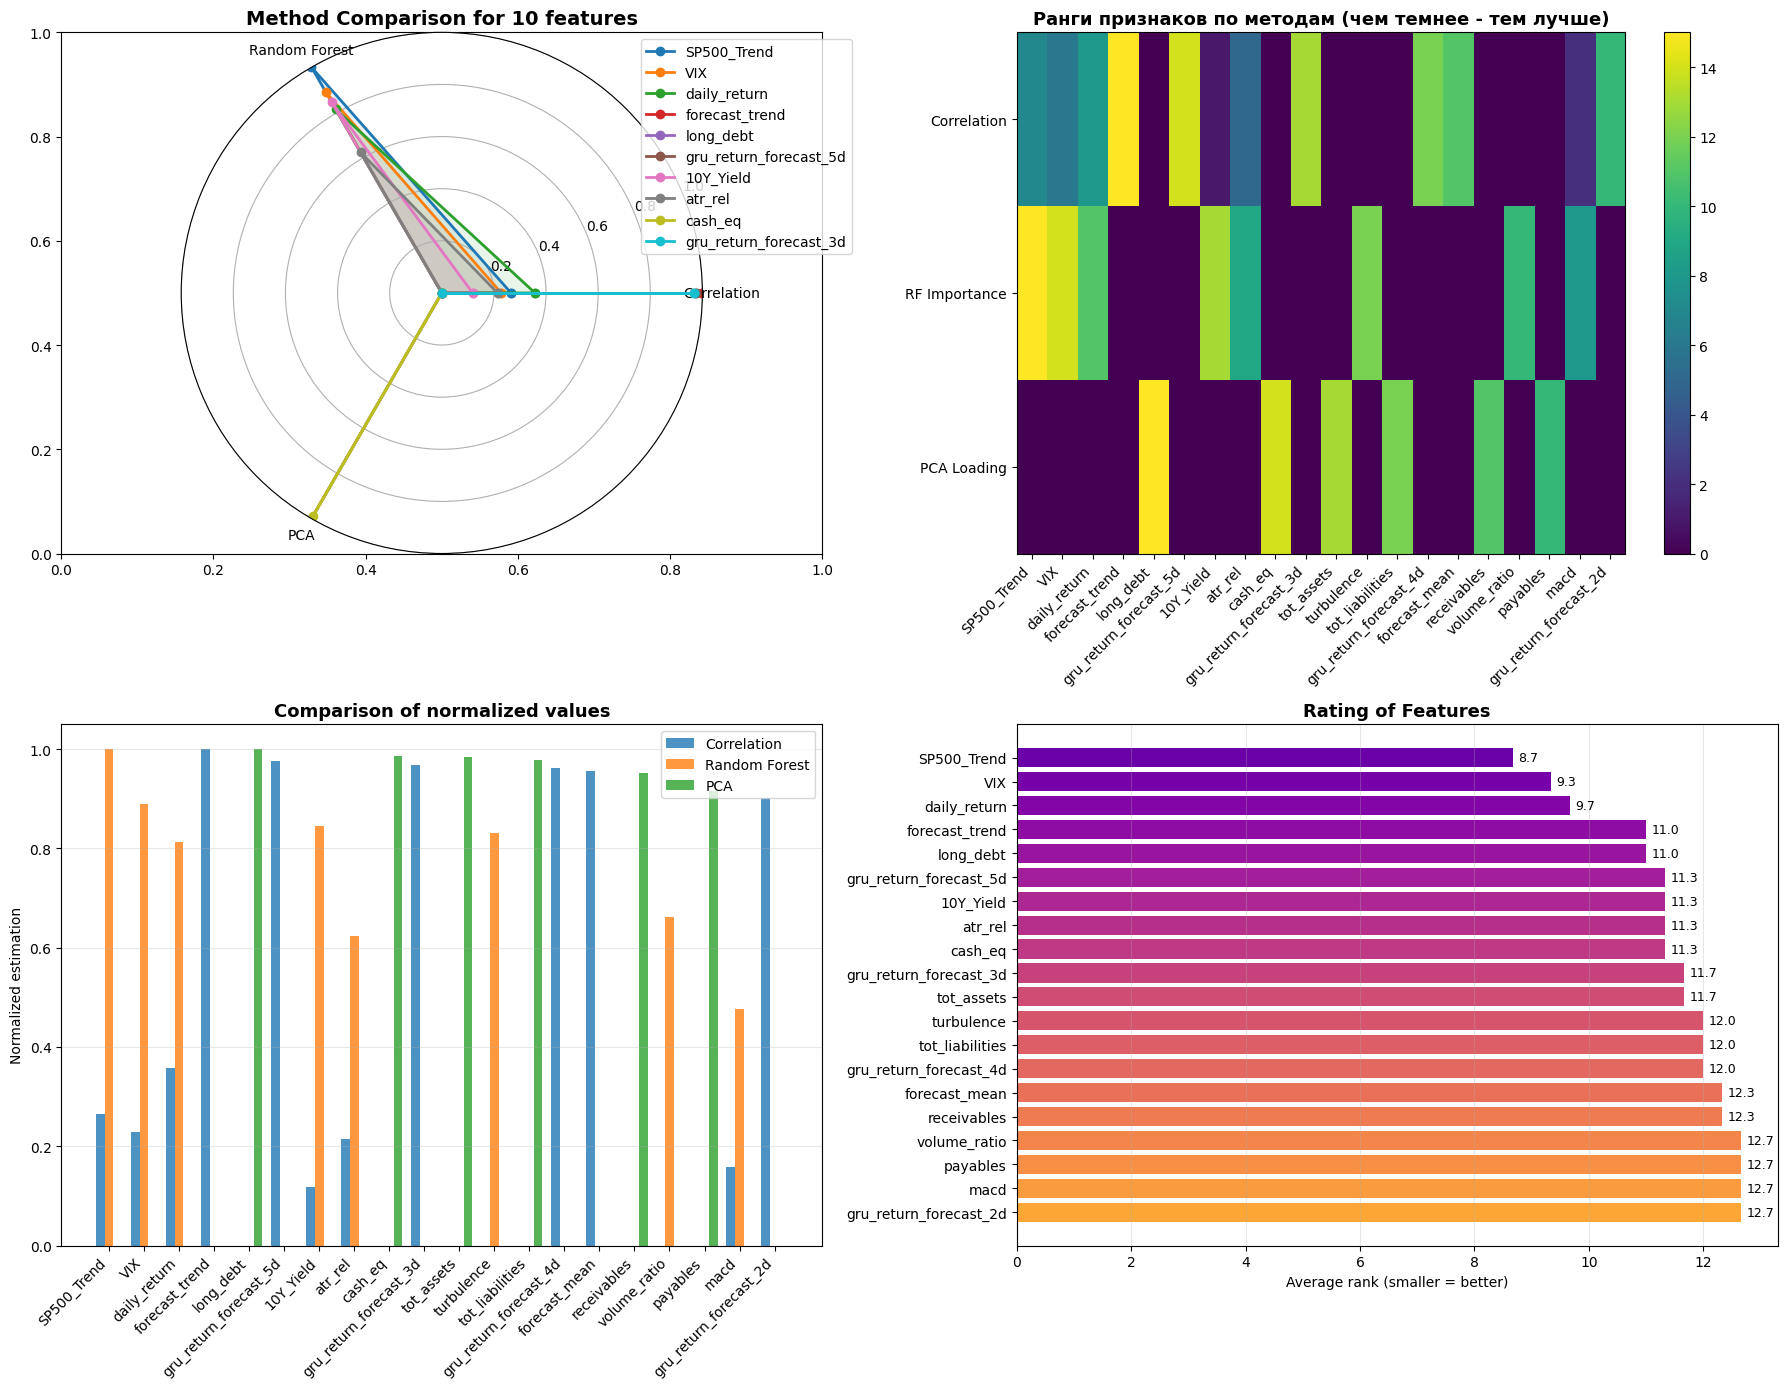

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def plot_comparative_analysis(correlations, importance_df, loadings, top_n=15):
    """
    Combined chart comparing three feature-selection methods
    """
    # Data preparation
    # 1. Correlations
    corr_features = [f[0] for f in correlations[:top_n]]
    corr_scores = [abs(f[1]) for f in correlations[:top_n]]

    # 2. Feature importance
    imp_features = importance_df.head(top_n)['feature'].tolist()
    imp_scores = importance_df.head(top_n)['importance'].tolist()

    # 3. PCA loadings
    pca_features = loadings['PC1'].abs().sort_values(ascending=False).head(top_n).index.tolist()
    pca_scores = loadings['PC1'].abs().sort_values(ascending=False).head(top_n).values.tolist()

    # Find shared features
    all_features = set(corr_features) | set(imp_features) | set(pca_features)

    # Create a comparison DataFrame
    comparison_data = []
    for feature in all_features:
        row = {'feature': feature}

        # Extract ranks from each method
        row['corr_rank'] = corr_features.index(feature) + 1 if feature in corr_features else top_n + 1
        row['rf_rank'] = imp_features.index(feature) + 1 if feature in imp_features else top_n + 1
        row['pca_rank'] = pca_features.index(feature) + 1 if feature in pca_features else top_n + 1

        # Normalized scores
        row['corr_score'] = corr_scores[corr_features.index(feature)] if feature in corr_features else 0
        row['rf_score'] = imp_scores[imp_features.index(feature)] if feature in imp_features else 0
        row['pca_score'] = pca_scores[pca_features.index(feature)] if feature in pca_features else 0

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)

    # Normalize scores for comparison
    for col in ['corr_score', 'rf_score', 'pca_score']:
        comparison_df[f'{col}_norm'] = comparison_df[col] / comparison_df[col].max()

    # Take the top-20 features by the sum of ranks
    comparison_df['avg_rank'] = comparison_df[['corr_rank', 'rf_rank', 'pca_rank']].mean(axis=1)
    comparison_df = comparison_df.sort_values('avg_rank').head(20)

    # Create the chart
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # Plot 1: Radar chart for the top features
    top5 = comparison_df.head(10)['feature'].tolist()

    # Data for the radar chart
    categories = ['Correlation', 'Random Forest', 'PCA']
    N = len(categories)

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    ax1 = fig.add_subplot(2, 2, 1, polar=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))

    for idx, feature in enumerate(top5):
        row = comparison_df[comparison_df['feature'] == feature].iloc[0]
        values = [row['corr_score_norm'], row['rf_score_norm'], row['pca_score_norm']]
        values += values[:1]

        ax1.plot(angles, values, 'o-', linewidth=2, label=feature, color=colors[idx])
        ax1.fill(angles, values, alpha=0.1, color=colors[idx])

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(categories)
    ax1.set_ylim(0, 1)
    ax1.set_title('Method Comparison for 10 features', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    # Plot 2: Rank heatmap
    ax2 = axes[0, 1]
    rank_data = comparison_df.set_index('feature')[['corr_rank', 'rf_rank', 'pca_rank']]

    # Invert ranks for clearer visualization (1 = best)
    rank_data_inv = (top_n + 1) - rank_data

    im2 = ax2.imshow(rank_data_inv.T, cmap='viridis', aspect='auto')
    ax2.set_xticks(range(len(rank_data)))
    ax2.set_xticklabels(rank_data.index, rotation=45, ha='right')
    ax2.set_yticks(range(3))
    ax2.set_yticklabels(['Correlation', 'RF Importance', 'PCA Loading'])
    ax2.set_title('Ранги признаков по методам (чем темнее - тем лучше)',
                 fontsize=13, fontweight='bold')

    plt.colorbar(im2, ax=ax2)

    # Plot 3: Comparison of normalized scores
    ax3 = axes[1, 0]

    x = np.arange(len(comparison_df))
    width = 0.25

    bars1 = ax3.bar(x - width, comparison_df['corr_score_norm'], width,
                    label='Correlation', alpha=0.8)
    bars2 = ax3.bar(x, comparison_df['rf_score_norm'], width,
                    label='Random Forest', alpha=0.8)
    bars3 = ax3.bar(x + width, comparison_df['pca_score_norm'], width,
                    label='PCA', alpha=0.8)

    ax3.set_xticks(x)
    ax3.set_xticklabels(comparison_df['feature'], rotation=45, ha='right')
    ax3.set_ylabel('Normalized estimation')
    ax3.set_title('Comparison of normalized values',
                 fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

    # Plot 4: Consensus (average rank)
    ax4 = axes[1, 1]

    # Sort by average rank
    consensus_df = comparison_df.sort_values('avg_rank')

    colors_consensus = plt.cm.plasma(np.linspace(0.2, 0.8, len(consensus_df)))
    bars = ax4.barh(consensus_df['feature'], consensus_df['avg_rank'],
                    color=colors_consensus)

    ax4.set_xlabel('Average rank (smaller = better)')
    ax4.set_title('Rating of Features',
                 fontsize=13, fontweight='bold')
    ax4.invert_yaxis()  # Best features on top
    ax4.grid(axis='x', alpha=0.3)

    # Add values
    for bar in bars:
        width = bar.get_width()
        ax4.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    return fig, comparison_df

# Usage
fig4, comparison_df = plot_comparative_analysis(correlations, importance_df, loadings, top_n=15)
plt.show()

AttributeError: 'Index' object has no attribute 'to_period'

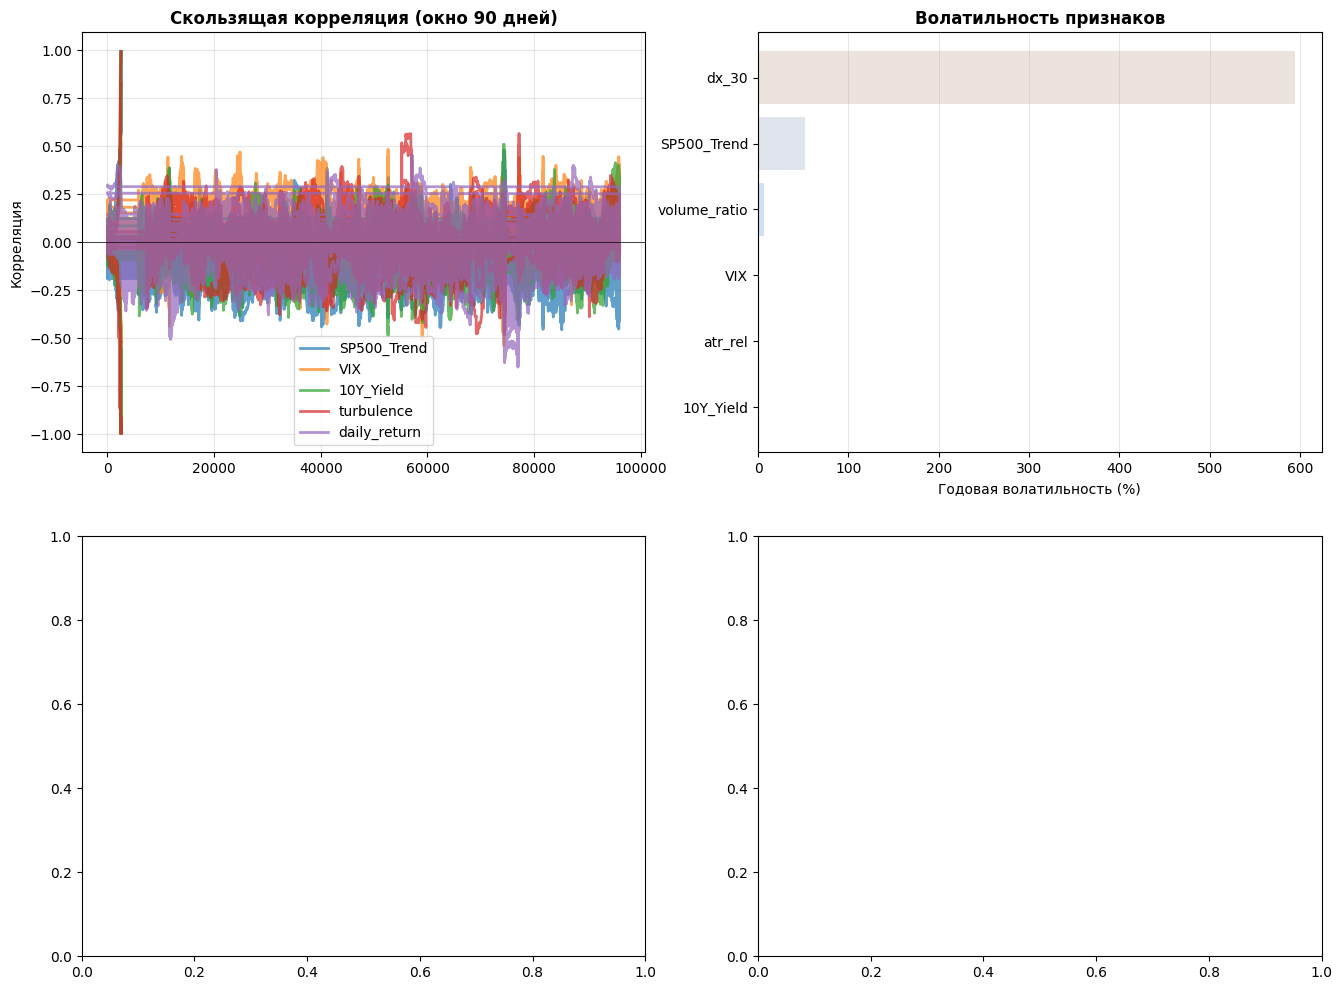

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_temporal_feature_stability(data, selected_features, window_days=90):
    """
    Temporal stability analysis of feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Rolling correlation for the top-5 features
    top_features = selected_features[:5]

    for feature in top_features:
        # Rolling correlation with the target variable
        rolling_corr = data[feature].rolling(window=window_days).corr(
            data['close'].pct_change().shift(-1)
        )
        axes[0, 0].plot(rolling_corr.index, rolling_corr.values,
                       label=feature, linewidth=2, alpha=0.7)

    axes[0, 0].set_title(f'Скользящая корреляция (окно {window_days} дней)',
                        fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Корреляция')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 2. Volatility of feature importance
    volatility_data = []
    for feature in selected_features[:10]:
        feature_series = data[feature].dropna()
        # Variability measure (standard deviation of changes)
        volatility = feature_series.pct_change().std() * np.sqrt(252)  # Годовая волатильность
        volatility_data.append((feature, volatility))

    volatility_df = pd.DataFrame(volatility_data, columns=['feature', 'volatility'])
    volatility_df = volatility_df.sort_values('volatility')

    colors_vol = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(volatility_df)))
    axes[0, 1].barh(volatility_df['feature'], volatility_df['volatility'],
                    color=colors_vol, alpha=0.7)
    axes[0, 1].set_title('Волатильность признаков', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Годовая волатильность (%)')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # 3. Heatmap of feature importance by period (quarters)
    data['quarter'] = data.index.to_period('Q')
    quarterly_importance = []

    for quarter in sorted(data['quarter'].unique())[-8:]:  # Last 8 quarters
        quarter_data = data[data['quarter'] == quarter]
        if len(quarter_data) > 30:  # At least 30 observations
            correlations_q = []
            target_q = quarter_data['close'].pct_change().shift(-1)

            for feature in selected_features[:15]:
                corr = quarter_data[feature].corr(target_q)
                correlations_q.append(abs(corr) if not pd.isna(corr) else 0)

            quarterly_importance.append(correlations_q)

    if quarterly_importance:
        quarterly_df = pd.DataFrame(
            quarterly_importance,
            columns=selected_features[:15],
            index=sorted(data['quarter'].unique())[-len(quarterly_importance):]
        )

        im = axes[1, 0].imshow(quarterly_df.T, cmap='YlOrRd', aspect='auto')
        axes[1, 0].set_xticks(range(len(quarterly_df)))
        axes[1, 0].set_xticklabels([str(q) for q in quarterly_df.index], rotation=45)
        axes[1, 0].set_yticks(range(len(quarterly_df.columns)))
        axes[1, 0].set_yticklabels(quarterly_df.columns)
        axes[1, 0].set_title('Важность признаков по кварталам',
                           fontsize=12, fontweight='bold')
        plt.colorbar(im, ax=axes[1, 0])

    # 4. Method-consensus matrix
    consensus_matrix = np.zeros((len(selected_features[:10]), 3))

    for i, feature in enumerate(selected_features[:10]):
        # Correlation
        corr_rank = next((idx for idx, (f, _) in enumerate(correlations)
                         if f == feature), 100)
        consensus_matrix[i, 0] = 1 / (corr_rank + 1)  # Inverse rank

        # Random Forest
        rf_row = importance_df[importance_df['feature'] == feature]
        consensus_matrix[i, 1] = rf_row['importance'].values[0] if not rf_row.empty else 0

        # PCA
        if feature in loadings.index:
            consensus_matrix[i, 2] = abs(loadings.loc[feature, 'PC1'])

    # Normalization
    consensus_matrix = consensus_matrix / consensus_matrix.max(axis=0)

    x = np.arange(len(selected_features[:10]))
    width = 0.25

    axes[1, 1].bar(x - width, consensus_matrix[:, 0], width,
                   label='Correlation', alpha=0.8, color='blue')
    axes[1, 1].bar(x, consensus_matrix[:, 1], width,
                   label='RF Importance', alpha=0.8, color='green')
    axes[1, 1].bar(x + width, consensus_matrix[:, 2], width,
                   label='PCA Loading', alpha=0.8, color='red')

    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(selected_features[:10], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Нормализованная оценка')
    axes[1, 1].set_title('Консенсус методов по топ-10 признакам',
                        fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.suptitle('АНАЛИЗ СТАБИЛЬНОСТИ И КОНСЕНСУСА ПРИЗНАКОВ',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    return fig

# Usage
fig5 = plot_temporal_feature_stability(processed, selected_features, window_days=90)
plt.show()

#### Why the Notebook Retains GRU Forecasts in the Final Feature Set

- The GRU forecasts already summarize recent price dynamics because they are trained on the market panel.
- PCA suggests that the forecast variables carry a large share of the dominant low-dimensional signal.
- Retaining the forecasts while dropping redundant raw-price inputs helps reduce multicollinearity.
- The final working set therefore favors compact forecast features over duplicate raw-price columns.

### 2.3 Final State-Space Feature List

In [ ]:
def check_final_vif(data, features):
    """VIF check for the final feature set."""
    df = data[features].copy().fillna(method='ffill')

    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(len(df.columns))
    ]

    vif_data = vif_data.sort_values("VIF", ascending=False)

    print("Мультиколлинеарность финального набора:")
    print(vif_data.to_string())
    print(f"\nМаксимальный VIF: {vif_data['VIF'].max():.2f}")
    print(f"Средний VIF: {vif_data['VIF'].mean():.2f}")

    # Threshold check
    high_vif = vif_data[vif_data['VIF'] > 10]
    moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]

    if len(high_vif) > 0:
        print(f"\n⚠️  ВНИМАНИЕ: {len(high_vif)} признаков с VIF > 10:")
        print(high_vif[['feature', 'VIF']].to_string())
    else:
        print("✓ Нет признаков с VIF > 10")

    return vif_data

In [3]:
# Final list of columns for the state space
RL_FEATURES =[
    # Macro and ML features
    'Regime_1_Prob', 'SP500_Trend', 'forecast_std',
    'gru_return_forecast_1d', 'gru_return_forecast_5d',

    # Risk features
    'turbulence', '10Y_Yield', 'VIX', 'atr_rel',

    # Technical and volume features
    'daily_return', 'macd', 'rsi_30', 'cci_30', 'dx_30',
    'volume_ratio', 'obv_pct_change',

    # Fundamental features
    'PE_ratio', 'PB_ratio', 'dividend_yield',
    'debt_ratio', 'revenue_growth', 'EV_EBITDA'
]



In [ ]:
# 3. Check VIF
print("Проверка финального набора...")
final_vif = check_final_vif(processed,RL_FEATURES)

Проверка финального набора...


/tmp/ipykernel_1167/3380345563.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = data[features].copy().fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Мультиколлинеарность финального набора:
                   feature        VIF
11                  rsi_30  72.440208
7                      VIX  29.063325
6                10Y_Yield  13.203939
8                  atr_rel  13.158346
19              debt_ratio  12.701806
4   gru_return_forecast_5d   8.179149
3   gru_return_forecast_1d   7.752592
14            volume_ratio   7.272152
0            Regime_1_Prob   4.070550
13                   dx_30   3.232210
17                PB_ratio   3.219970
16                PE_ratio   3.150134
1              SP500_Trend   3.106785
18          dividend_yield   3.008372
12                  cci_30   2.343266
5               turbulence   2.109806
2             forecast_std   1.826311
10                    macd   1.689306
20          revenue_growth   1.346142
9             daily_return   1.141697
21               EV_EBITDA   1.036030
15          obv_pct_change   1.000133

Максимальный VIF: 72.44
Средний VIF: 8.91

⚠️  ВНИМАНИЕ: 5 признаков с VIF > 10:
    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Create the final dataset for the environment
final_rl_df = processed[['date', 'tic', 'close'] + RL_FEATURES] # 'close' is only needed by the environment to compute portfolio value

In [5]:
final_rl_df.shape

(96019, 25)

## 3. Train / Validation / Frozen-Test Setup

In [6]:
final_rl_df = final_rl_df.sort_values(['date', 'tic']).reset_index(drop=True)

In [7]:
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)

TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2021-10-01'
VAL_START_DATE = '2021-10-01'
VAL_END_DATE = '2022-01-03'
TEST_START_DATE = '2022-01-03'
TEST_END_DATE = '2023-03-01'


In [8]:
# Data split: train -> validation -> frozen test
train_start = TRAIN_START_DATE
train_end = TRAIN_END_DATE
val_start = VAL_START_DATE
val_end = VAL_END_DATE
test_start = TEST_START_DATE
test_end = TEST_END_DATE


In [9]:
train = data_split(final_rl_df, train_start, train_end)
validation = data_split(final_rl_df, val_start, val_end)
test = data_split(final_rl_df, test_start, test_end)

# Backward-compatible alias: trade is used only for validation/model selection.
trade = validation.copy()

print(f"Train dates: {train.date.min()} to {train.date.max()}")
print(f"Validation dates: {validation.date.min()} to {validation.date.max()}")
print(f"Frozen test dates: {test.date.min()} to {test.date.max()}")

assert train.date.max() < validation.date.min(), "Validation must start strictly after train."
assert validation.date.max() < test.date.min(), "Test must start strictly after validation."


Train dates: 2010-01-04 00:00:00 to 2021-09-30 00:00:00
Validation dates: 2021-10-01 00:00:00 to 2021-12-31 00:00:00
Frozen test dates: 2022-01-03 00:00:00 to 2023-02-28 00:00:00


In [ ]:
A2C_model_kwargs = {
                    'n_steps': 5,
                    'ent_coef': 0.005,
                    'learning_rate': 0.0007
                    }

PPO_model_kwargs = {
                    "ent_coef":0.01,
                    "n_steps": 2048,
                    "learning_rate": 0.00025,
                    "batch_size": 128
                    }

DDPG_model_kwargs = {
                      #"action_noise":"ornstein_uhlenbeck",
                      "buffer_size": 10_000,
                      "learning_rate": 0.0005,
                      "batch_size": 64
                    }

In [10]:
stock_dimension = len(train['tic'].unique())

# State-space formula: [cash balance] + [close prices for all stocks] + [shares held] + [indicators x stock dimension]
state_space = 1 + (2 * stock_dimension) + (len(RL_FEATURES) * stock_dimension)
print(f"Количество акций: {stock_dimension}")
print(f"Размерность State Space: {state_space}")

env_kwargs = {
    "hmax": 100,                                 # Maximum number of shares per trade
    "initial_amount": 1000000,                   # Initial capital ($1M)
    "num_stock_shares": [0] * stock_dimension,   # Start with zero shares of each company
    "buy_cost_pct": [0.001] * stock_dimension,   # Buy commission (0.1%)
    "sell_cost_pct": [0.001] * stock_dimension,  # Sell commission (0.1%)
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": RL_FEATURES,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4                       # Reward scaling (important for PPO convergence)
}


Количество акций: 29
Размерность State Space: 697


In [11]:
#Establish the training environment using StockTradingEnv() class
e_train_gym = StockTradingEnv(df = train, **env_kwargs)

In [12]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


### 3.1 Train Out-of-the-Box Reference Agents

In [ ]:
agent = DRLAgent(env = env_train)

model_ppo = agent.get_model("ppo",model_kwargs = PPO_model_kwargs)
trained_ppo = agent.train_model(model=model_ppo,
                             tb_log_name='ppo',
                             total_timesteps=100000)

In [ ]:
agent = DRLAgent(env = env_train)
model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_model_kwargs)
trained_ddpg = agent.train_model(model=model_ddpg,
                             tb_log_name='ddpg',
                             total_timesteps=100000)

In [ ]:
agent = DRLAgent(env = env_train)
model_a2c = agent.get_model("a2c",model_kwargs = A2C_model_kwargs)
trained_a2c = agent.train_model(model=model_a2c,
                             tb_log_name='a2c',
                             total_timesteps=100900)

In [ ]:
e_val_gym = StockTradingEnv(df=validation, **env_kwargs)


In [ ]:
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment=e_val_gym)


In [ ]:
df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
    model=trained_ddpg,
    environment=e_val_gym)

df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c,
    environment=e_val_gym)


### 3.2 Backtest the Out-of-the-Box Agents

In [ ]:
perf_stats_ppo = backtest_stats(account_value=df_account_value_ppo)
perf_stats_ppo = pd.DataFrame(perf_stats_ppo)

In [ ]:
perf_stats_ppo

In [ ]:
perf_stats_ddpg = backtest_stats(account_value=df_account_value_ddpg)
perf_stats_ddpg = pd.DataFrame(perf_stats_ddpg)

In [ ]:
perf_stats_a2c = backtest_stats(account_value=df_account_value_a2c)
perf_stats_a2c = pd.DataFrame(perf_stats_a2c)

In [15]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI",
        start = df_account_value_ppo.loc[0,'date'],
        end = df_account_value_ppo.loc[len(df_account_value_ppo)-1,'date'])

perf_stats_dji = backtest_stats(df_dji_, value_col_name = 'close')

==============Get Baseline Stats===========


NameError: name 'df_account_value_ppo' is not defined

## 4. PPO Configuration Design

This section builds the six PPO combinations formed by three reward environments and two policy-network variants.

### 4.1 Reward-Function Variants

#### 4.1.1 Quadratic-Utility Reward Environment

In [13]:
class CustomStockTradingEnv(StockTradingEnv):
    """
    Environment with quadratic utility reward.
    Adapted for a multi-asset portfolio.
    """
    def __init__(self, *args, sigma_target=0.15/252**0.5, lambda_param=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.sigma_target = sigma_target
        self.lambda_param = lambda_param
        self.returns_history = []
        self.window_size = 20

    def _get_total_asset(self):
        prices = np.asarray(self.state[1 : 1 + self.stock_dim], dtype=float)
        shares = np.asarray(self.state[1 + self.stock_dim : 1 + (2 * self.stock_dim)], dtype=float)
        cash = float(self.state[0])
        return float(cash + np.dot(prices, shares))

    def _get_scale_factor(self):
        hist = self.returns_history[-self.window_size :]
        current_sigma = np.std(hist) if len(hist) > 1 else 0.01
        current_sigma = max(current_sigma, 1e-4)
        return self.sigma_target / current_sigma

    def step(self, actions):
        # Measure capital as total assets, not just the cash component state[0]
        asset_before = self._get_total_asset()
        scale_factor = self._get_scale_factor()

        # Execute the step through the parent class (it handles trades and commissions)
        step_result = super().step(actions)

        # Support different gym versions (the step may return 4 or 5 elements)
        if len(step_result) == 5:
            state, base_reward, done, truncated, info = step_result
        else:
            state, base_reward, done, info = step_result
            truncated = False

        asset_after = self._get_total_asset()
        port_return = (asset_after - asset_before) / asset_before if asset_before > 0 else 0.0

        # Quadratic utility: U = r - λ * r^2
        utility = port_return - self.lambda_param * (port_return ** 2)
        custom_reward = scale_factor * utility * asset_before * self.reward_scaling

        self.returns_history.append(port_return)
        if len(self.returns_history) > self.window_size:
            self.returns_history.pop(0)

        if len(step_result) == 5:
            return state, custom_reward, done, truncated, info
        return state, custom_reward, done, info


#### 4.1.2 Zhang et al. Reward Environment

In [14]:
class ZhangStockTradingEnv(StockTradingEnv):
    """
    Environment with the reward from Zhang et al. (2019).
    """
    def __init__(self, *args, sigma_target=0.15/252**0.5, mu=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.sigma_target = sigma_target
        self.mu = mu
        self.returns_history = []
        self.window_size = 20

    def _get_total_asset(self):
        prices = np.asarray(self.state[1 : 1 + self.stock_dim], dtype=float)
        shares = np.asarray(self.state[1 + self.stock_dim : 1 + (2 * self.stock_dim)], dtype=float)
        cash = float(self.state[0])
        return float(cash + np.dot(prices, shares))

    def _get_scale_factor(self):
        hist = self.returns_history[-self.window_size :]
        current_sigma = np.std(hist) if len(hist) > 1 else 0.01
        current_sigma = max(current_sigma, 1e-4)
        return self.sigma_target / current_sigma

    def step(self, actions):
        asset_before = self._get_total_asset()
        scale_factor = self._get_scale_factor()

        step_result = super().step(actions)
        if len(step_result) == 5:
            state, base_reward, done, truncated, info = step_result
        else:
            state, base_reward, done, info = step_result
            truncated = False

        asset_after = self._get_total_asset()
        port_return = (asset_after - asset_before) / asset_before if asset_before > 0 else 0.0
        custom_reward = self.mu * scale_factor * port_return * asset_before * self.reward_scaling

        self.returns_history.append(port_return)
        if len(self.returns_history) > self.window_size:
            self.returns_history.pop(0)

        if len(step_result) == 5:
            return state, custom_reward, done, truncated, info
        return state, custom_reward, done, info


#### 4.1.3 FinRL Reward Environment

In [15]:
sigma_target = 0.15 / (252 ** 0.5)  # Target volatility (15% annualized)
lambda_param = 0.01  # Risk-aversion coefficient for the custom reward
mu_param = 1.0  # Scaling coefficient for the Zhang reward
finrl_policy_kwargs = None

### 4.2 Custom Policy-Network Variant

In [16]:
custom_policy_kwargs = dict(
    net_arch=dict(
        pi=[256, 128, 64],
        vf=[256, 128, 64]
    ),
    activation_fn=torch.nn.ReLU,
    ortho_init=True
)

### 4.3 Assemble the Six PPO Configurations

In [17]:
# ==================== CREATE ALL 6 CONFIGURATIONS ====================
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": [0.001] * stock_dimension,
    "sell_cost_pct": [0.001] * stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": RL_FEATURES,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity": 5,
}

def build_env_bundle(env_cls, policy_kwargs, extra_kwargs=None):
    extra_kwargs = extra_kwargs or {}
    common_kwargs = {**env_kwargs, **extra_kwargs}

    train_env = env_cls(df=train, num_stock_shares=[0] * stock_dimension, **common_kwargs)
    env_train, _ = train_env.get_sb_env()

    validation_env = env_cls(
        df=validation,
        num_stock_shares=[0] * stock_dimension,
        turbulence_threshold=70,
        risk_indicator_col='turbulence',
        **common_kwargs,
    )

    test_env = env_cls(
        df=test,
        num_stock_shares=[0] * stock_dimension,
        turbulence_threshold=70,
        risk_indicator_col='turbulence',
        **common_kwargs,
    )

    return env_train, train_env, validation_env, test_env, policy_kwargs

env_configs = {
    'finrl_finrl': (StockTradingEnv, finrl_policy_kwargs, {}),
    'finrl_custom': (StockTradingEnv, custom_policy_kwargs, {}),
    'zhang_finrl': (ZhangStockTradingEnv, finrl_policy_kwargs, {'sigma_target': sigma_target, 'mu': mu_param}),
    'zhang_custom': (ZhangStockTradingEnv, custom_policy_kwargs, {'sigma_target': sigma_target, 'mu': mu_param}),
    'custom_finrl': (CustomStockTradingEnv, finrl_policy_kwargs, {'sigma_target': sigma_target, 'lambda_param': lambda_param}),
    'custom_custom': (CustomStockTradingEnv, custom_policy_kwargs, {'sigma_target': sigma_target, 'lambda_param': lambda_param}),
}

train_environments = {}
validation_environments = {}
test_environments = {}

for config_name, (env_cls, policy_kwargs, extra_kwargs) in env_configs.items():
    env_train, train_env, validation_env, test_env, policy_kwargs = build_env_bundle(
        env_cls=env_cls,
        policy_kwargs=policy_kwargs,
        extra_kwargs=extra_kwargs,
    )
    train_environments[config_name] = (env_train, train_env, policy_kwargs)
    validation_environments[config_name] = validation_env
    test_environments[config_name] = test_env

# Backward-compatible alias: trade envs now mean validation envs only.
trade_environments = validation_environments


### 4.4 Train and Evaluate the Six PPO Configurations

## 5. Stable Training Study: Early Stopping and Dropout

In [18]:
import os
import re
import glob
import json
import shutil
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback,
    EvalCallback,
    StopTrainingOnNoModelImprovement,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.plot import backtest_stats


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="ipywidgets.widgets.widget_output")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="ipykernel.kernelbase")


def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [19]:
state_space

697

In [20]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class CustomDropoutExtractor(BaseFeaturesExtractor):
    def __init__(
        self,
        observation_space,
        features_dim=256,
        hidden_dims=(512, 256),
        dropout_p=0.1,
    ):
        super().__init__(observation_space, features_dim)

        input_dim = observation_space.shape[0]
        layers = []

        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, features_dim))
        layers.append(nn.ReLU())

        self.extractor = nn.Sequential(*layers)

    def forward(self, observations):
        return self.extractor(observations)



In [21]:
def build_custom_policy_kwargs(
    dropout_p=0.1,
    features_dim=256,
    hidden_dims=(512, 256),
    pi_arch=(256, 128, 64),
    vf_arch=(256, 128, 64),
):
    return dict(
        features_extractor_class=CustomDropoutExtractor,
        features_extractor_kwargs=dict(
            features_dim=features_dim,
            hidden_dims=hidden_dims,
            dropout_p=dropout_p,
        ),
        net_arch=dict(
            pi=list(pi_arch),
            vf=list(vf_arch),
        ),
        activation_fn=torch.nn.ReLU,
        ortho_init=True,
    )

In [22]:
PPO_model_kwargs = {
    "learning_rate": 1e-4,
    "n_steps": 4096,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.02,
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "device": "cpu",
}


In [23]:
def wrap_eval_env(eval_env):
    if isinstance(eval_env, DummyVecEnv):
        # If this is already a VecEnv, add VecMonitor if it is not wrapped yet
        if not isinstance(eval_env, VecMonitor):
            eval_env = VecMonitor(eval_env)
        return eval_env
    else:
        return Monitor(eval_env)

In [24]:
def build_callbacks(
    eval_env,
    run_dir,
    es_mode="current",
    eval_freq=4096,
    checkpoint_freq=4096,
    verbose=1,
):
    os.makedirs(run_dir, exist_ok=True)
    best_model_dir = os.path.join(run_dir, "best_model")
    checkpoints_dir = os.path.join(run_dir, "checkpoints")
    logs_dir = os.path.join(run_dir, "eval_logs")

    os.makedirs(best_model_dir, exist_ok=True)
    os.makedirs(checkpoints_dir, exist_ok=True)
    os.makedirs(logs_dir, exist_ok=True)

    eval_env = wrap_eval_env(eval_env)

    checkpoint_callback = CheckpointCallback(
        save_freq=checkpoint_freq,
        save_path=checkpoints_dir,
        name_prefix="rl_model",
        save_replay_buffer=False,
        save_vecnormalize=False,
        verbose=verbose,
    )

    callback_list = [checkpoint_callback]

    if es_mode == "current":
        stop_callback = StopTrainingOnNoModelImprovement(
            max_no_improvement_evals=5,
            min_evals=3,
            verbose=verbose,
        )
    elif es_mode == "relaxed":
        stop_callback = StopTrainingOnNoModelImprovement(
            max_no_improvement_evals=10,
            min_evals=8,
            verbose=verbose,
        )
    elif es_mode == "none":
        stop_callback = None
    else:
        raise ValueError(f"Unknown es_mode: {es_mode}")

    eval_callback = EvalCallback(
        eval_env=eval_env,
        callback_after_eval=stop_callback,
        best_model_save_path=best_model_dir,
        log_path=logs_dir,
        eval_freq=eval_freq,
        deterministic=True,
        render=False,
        n_eval_episodes=3,
        verbose=verbose,
    )
    callback_list.append(eval_callback)

    return CallbackList(callback_list), {
        "run_dir": run_dir,
        "best_model_dir": best_model_dir,
        "best_model_path": os.path.join(best_model_dir, "best_model.zip"),
        "checkpoints_dir": checkpoints_dir,
        "logs_dir": logs_dir,
    }

In [25]:
def extract_metric(stats, metric_name):
    if isinstance(stats, pd.Series):
        return stats.get(metric_name, np.nan)
    if isinstance(stats, dict):
        return stats.get(metric_name, np.nan)
    if isinstance(stats, pd.DataFrame):
        if metric_name in stats.index:
            value = stats.loc[metric_name]
            if isinstance(value, pd.Series):
                return value.iloc[0]
            return value
        if metric_name in stats.columns:
            return stats[metric_name].iloc[0]
    return np.nan

In [26]:
# --- 3. Proper early stopping (use the built-in SB3 tools) ---
def create_eval_callback(eval_env, model_name):
    # FinRL often returns DummyVecEnv. We need to wrap the underlying environment with Monitor
    if isinstance(eval_env, DummyVecEnv):
        # If the environment is already vectorized, unwrapping it for Monitor is cumbersome.
        # SB3's EvalCallback can work with DummyVecEnv directly!
        pass
    else:
        eval_env = Monitor(eval_env)

    # Built-in early stopping module (better and more stable than a custom version)
    stop_train_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=5, # Wait for 5 evaluations without improvement
        min_evals=3,                # Minimum number of evaluations before triggering
        verbose=1
    )

    eval_callback = EvalCallback(
        eval_env,
        callback_after_eval=stop_train_callback, # Link it to the early-stopping callback
        best_model_save_path=f"./best_models/{model_name}/",
        log_path=f"./logs/{model_name}/",
        eval_freq=4096,           # CHANGED: must be a multiple of n_steps (4096 here)!
        deterministic=True,       # Important: disable stochasticity (and dropout) during validation
        render=False,
        n_eval_episodes=3,
        verbose=1
    )

    return eval_callback

In [27]:
def evaluate_model_on_env(model, environment):
    df_account_value, df_action = DRLAgent.DRL_prediction(
        model=model,
        environment=environment
    )

    stats = backtest_stats(account_value=df_account_value)
    stats_df = pd.DataFrame(stats)

    initial_val = df_account_value.iloc[0, 1]
    final_val = df_account_value.iloc[-1, 1]
    returns_pct = ((final_val / initial_val) - 1) * 100
    sharpe_ratio = pd.to_numeric(extract_metric(stats, 'Sharpe ratio'), errors='coerce')
    max_dd = pd.to_numeric(extract_metric(stats, 'Max drawdown'), errors='coerce')
    annual_return = pd.to_numeric(extract_metric(stats, 'Annual return'), errors='coerce')

    return {
        "df_account_value": df_account_value,
        "df_action": df_action,
        "stats": stats,
        "stats_df": stats_df,
        "initial_val": initial_val,
        "final_val": final_val,
        "return_pct": returns_pct,
        "sharpe": sharpe_ratio,
        "max_drawdown": max_dd,
        "annual_return": annual_return,
    }

In [28]:
def parse_checkpoint_timestep(path):
    filename = os.path.basename(path)
    match = re.search(r"_(\d+)_steps\.zip$", filename)
    return int(match.group(1)) if match else -1

def list_checkpoints(checkpoints_dir):
    ckpts = glob.glob(os.path.join(checkpoints_dir, "*.zip"))
    ckpts = sorted(ckpts, key=parse_checkpoint_timestep)
    return ckpts

In [29]:
# Example structure.
# Plug in your actual environment classes and kwargs.

ENV_SPECS = {
    "finrl_finrl": {
        "train_env_class": StockTradingEnv,
        "val_env_class": StockTradingEnv,
        "test_env_class": StockTradingEnv,
        "train_kwargs": dict(df=train, num_stock_shares=[0]*stock_dimension, **env_kwargs),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": False,
    },

    "finrl_custom": {
        "train_env_class": StockTradingEnv,
        "val_env_class": StockTradingEnv,
        "test_env_class": StockTradingEnv,
        "train_kwargs": dict(df=train, num_stock_shares=[0]*stock_dimension, **env_kwargs),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": True,
    },

    "zhang_finrl": {
        "train_env_class": ZhangStockTradingEnv,
        "val_env_class": ZhangStockTradingEnv,
        "test_env_class": ZhangStockTradingEnv,
        "train_kwargs": dict(
            df=train,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            **env_kwargs
        ),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": False,
    },

    "zhang_custom": {
        "train_env_class": ZhangStockTradingEnv,
        "val_env_class": ZhangStockTradingEnv,
        "test_env_class": ZhangStockTradingEnv,
        "train_kwargs": dict(
            df=train,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            **env_kwargs
        ),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            mu=mu_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": True,
    },

    "custom_finrl": {
        "train_env_class": CustomStockTradingEnv,
        "val_env_class": CustomStockTradingEnv,
        "test_env_class": CustomStockTradingEnv,
        "train_kwargs": dict(
            df=train,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            **env_kwargs
        ),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": False,
    },

    "custom_custom": {
        "train_env_class": CustomStockTradingEnv,
        "val_env_class": CustomStockTradingEnv,
        "test_env_class": CustomStockTradingEnv,
        "train_kwargs": dict(
            df=train,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            **env_kwargs
        ),
        "val_kwargs": dict(
            df=validation,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "test_kwargs": dict(
            df=test,
            num_stock_shares=[0]*stock_dimension,
            sigma_target=sigma_target,
            lambda_param=lambda_param,
            turbulence_threshold=70,
            risk_indicator_col='turbulence',
            **env_kwargs
        ),
        "use_custom_policy": True,
    },
}

In [30]:
def make_train_env(config_name):
    spec = ENV_SPECS[config_name]
    e_train = spec["train_env_class"](**spec["train_kwargs"])
    env_train, _ = e_train.get_sb_env()
    return env_train, e_train

def make_validation_env(config_name):
    spec = ENV_SPECS[config_name]
    e_val = spec["val_env_class"](**spec["val_kwargs"])
    return e_val

def make_test_env(config_name):
    spec = ENV_SPECS[config_name]
    e_test = spec["test_env_class"](**spec["test_kwargs"])
    return e_test

In [31]:
def train_one_model(
    config_name,
    run_dir,
    total_timesteps=200000,
    seed=42,
    policy_kwargs=None,
    es_mode="current",
    eval_freq=4096,
    checkpoint_freq=4096,
    verbose=0,
):
    set_all_seeds(seed)

    env_train, e_train = make_train_env(config_name)
    e_val_for_callback = make_validation_env(config_name)

    agent = DRLAgent(env=env_train)

    if policy_kwargs is not None:
        model = agent.get_model(
            "ppo",
            model_kwargs=PPO_model_kwargs,
            policy_kwargs=policy_kwargs,
            verbose=verbose,
        )
    else:
        model = agent.get_model(
            "ppo",
            model_kwargs=PPO_model_kwargs,
            verbose=verbose,
        )

    callbacks, paths = build_callbacks(
        eval_env=e_val_for_callback,
        run_dir=run_dir,
        es_mode=es_mode,
        eval_freq=eval_freq,
        checkpoint_freq=checkpoint_freq,
        verbose=1,
    )

    trained_model = model.learn(
        total_timesteps=total_timesteps,
        tb_log_name=os.path.basename(run_dir),
        callback=callbacks,
        progress_bar=True,
    )

    last_model_path = os.path.join(run_dir, "last_model.zip")
    trained_model.save(last_model_path)

    paths["last_model_path"] = last_model_path
    paths["config_name"] = config_name
    paths["seed"] = seed
    paths["es_mode"] = es_mode

    meta_path = os.path.join(run_dir, "run_meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(paths, f, indent=2, ensure_ascii=False)

    return paths

In [32]:
def evaluate_saved_model(model_path, config_name):
    model = PPO.load(model_path)

    e_val = make_validation_env(config_name)
    val_result = evaluate_model_on_env(model, e_val)

    return {
        "model_path": model_path,
        "config_name": config_name,
        "validation_sharpe": val_result["sharpe"],
        "validation_return_pct": val_result["return_pct"],
        "validation_max_drawdown": val_result["max_drawdown"],
        "validation_annual_return": val_result["annual_return"],
    }

def evaluate_all_checkpoints_on_validation(checkpoints_dir, config_name):
    rows = []
    for ckpt_path in list_checkpoints(checkpoints_dir):
        row = evaluate_saved_model(ckpt_path, config_name)
        row["timestep"] = parse_checkpoint_timestep(ckpt_path)
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=[
            "model_path", "config_name", "validation_sharpe",
            "validation_return_pct", "validation_max_drawdown",
            "validation_annual_return", "timestep"
        ])

    df = pd.DataFrame(rows).sort_values("timestep").reset_index(drop=True)
    return df

In [33]:
def select_best_artifact_for_run(paths):
    config_name = paths["config_name"]

    candidate_rows = []

    if os.path.exists(paths["best_model_path"]):
        row = evaluate_saved_model(paths["best_model_path"], config_name)
        row["artifact_type"] = "best_model"
        row["timestep"] = np.nan
        candidate_rows.append(row)

    if os.path.exists(paths["last_model_path"]):
        row = evaluate_saved_model(paths["last_model_path"], config_name)
        row["artifact_type"] = "last_model"
        row["timestep"] = np.nan
        candidate_rows.append(row)

    ckpt_df = evaluate_all_checkpoints_on_validation(paths["checkpoints_dir"], config_name)
    if not ckpt_df.empty:
        best_ckpt_row = ckpt_df.sort_values(
            ["validation_sharpe", "validation_return_pct"],
            ascending=[False, False]
        ).iloc[0].to_dict()
        best_ckpt_row["artifact_type"] = "best_checkpoint_by_validation"
        candidate_rows.append(best_ckpt_row)

    candidate_df = pd.DataFrame(candidate_rows)
    candidate_df = candidate_df.sort_values(
        ["validation_sharpe", "validation_return_pct"],
        ascending=[False, False],
        na_position="last"
    ).reset_index(drop=True)

    selected = candidate_df.iloc[0].to_dict()
    return candidate_df, selected, ckpt_df

In [34]:
def final_test_model(model_path, config_name):
    model = PPO.load(model_path)
    e_test = make_test_env(config_name)
    test_result = evaluate_model_on_env(model, e_test)
    return test_result

In [35]:
def run_single_experiment(
    config_name,
    run_dir,
    seed=42,
    total_timesteps=200000,
    policy_kwargs=None,
    es_mode="current",
):
    paths = train_one_model(
        config_name=config_name,
        run_dir=run_dir,
        total_timesteps=total_timesteps,
        seed=seed,
        policy_kwargs=policy_kwargs,
        es_mode=es_mode,
        eval_freq=4096 if es_mode != "relaxed" else 8192,
        checkpoint_freq=4096,
        verbose=0,
    )

    candidate_df, selected_artifact, ckpt_df = select_best_artifact_for_run(paths)

    test_result = final_test_model(
        model_path=selected_artifact["model_path"],
        config_name=config_name
    )

    summary = {
        "config_name": config_name,
        "seed": seed,
        "es_mode": es_mode,
        "selected_artifact_type": selected_artifact["artifact_type"],
        "selected_model_path": selected_artifact["model_path"],
        "validation_sharpe": selected_artifact["validation_sharpe"],
        "validation_return_pct": selected_artifact["validation_return_pct"],
        "test_sharpe": test_result["sharpe"],
        "test_return_pct": test_result["return_pct"],
        "test_max_drawdown": test_result["max_drawdown"],
    }

    return {
        "paths": paths,
        "candidate_df": candidate_df,
        "checkpoint_df": ckpt_df,
        "selected_artifact": selected_artifact,
        "test_result": test_result,
        "summary": summary,
    }

In [52]:
def run_ablation_experiments(
    config_names,
    seeds=(42, 123, 999),
    es_modes=("current", "relaxed", "none"),
    dropout_ps=(0.0, 0.1),
    total_timesteps=200000,
    base_dir="./experiments_ablation",
):
    os.makedirs(base_dir, exist_ok=True)

    all_summaries = []
    detailed_results = {}

    for config_name in config_names:
        use_custom_policy = ENV_SPECS[config_name]["use_custom_policy"]

        for seed in seeds:
            for es_mode in es_modes:
                for dropout_p in dropout_ps:
                    if use_custom_policy:
                        policy_kwargs = build_custom_policy_kwargs(dropout_p=dropout_p)
                    else:
                        # Dropout does not apply to the FinRL policy, so keep it as None.
                        # To avoid duplicate runs, you can skip cases where dropout_p != 0.
                        if dropout_p != 0.0:
                            continue
                        policy_kwargs = None

                    run_name = f"{config_name}__seed{seed}__es-{es_mode}__dropout-{dropout_p}"
                    run_dir = os.path.join(base_dir, run_name)

                    print("\n" + "=" * 90)
                    print(f"RUN: {run_name}")
                    print("=" * 90)

                    result = run_single_experiment(
                        config_name=config_name,
                        run_dir=run_dir,
                        seed=seed,
                        total_timesteps=total_timesteps,
                        policy_kwargs=policy_kwargs,
                        es_mode=es_mode,
                    )

                    summary = result["summary"]
                    summary["dropout_p"] = dropout_p
                    all_summaries.append(summary)

                    detailed_results[run_name] = result

                    print("Selected artifact:", summary["selected_artifact_type"])
                    print("Validation Sharpe:", summary["validation_sharpe"])
                    print("Validation Return %:", summary["validation_return_pct"])
                    print("Test Sharpe:", summary["test_sharpe"])
                    print("Test Return %:", summary["test_return_pct"])

    summary_df = pd.DataFrame(all_summaries)
    summary_df = summary_df.sort_values(
        ["test_sharpe", "test_return_pct"],
        ascending=[False, False],
        na_position="last"
    ).reset_index(drop=True)

    summary_df.to_csv(os.path.join(base_dir, "ablation_summary.csv"), index=False)
    return summary_df, detailed_results

In [63]:
def run_ablation_experiments(
    config_names,
    seeds=(42, 123, 999),
    es_mode="relaxed",
    dropout_p=0.1,
    total_timesteps=200000,
    base_dir="./experiments_ablation",
):
    os.makedirs(base_dir, exist_ok=True)

    all_summaries = []
    detailed_results = {}

    for config_name in config_names:
        use_custom_policy = ENV_SPECS[config_name]["use_custom_policy"]

        for seed in seeds:
            if use_custom_policy:
                policy_kwargs = build_custom_policy_kwargs(dropout_p=dropout_p)
                effective_dropout_p = dropout_p
            else:
                # Dropout is not applied to the FinRL policy
                policy_kwargs = None
                effective_dropout_p = np.nan  # or 0.0, but NaN is more honest in the exports

            run_name = f"{config_name}__seed{seed}__es-{es_mode}__dropout-{effective_dropout_p}"
            run_dir = os.path.join(base_dir, run_name)

            print("\n" + "=" * 90)
            print(f"RUN: {run_name}")
            print("=" * 90)

            result = run_single_experiment(
                config_name=config_name,
                run_dir=run_dir,
                seed=seed,
                total_timesteps=total_timesteps,
                policy_kwargs=policy_kwargs,
                es_mode=es_mode,
            )

            summary = result["summary"]
            summary["dropout_p"] = effective_dropout_p
            all_summaries.append(summary)

            detailed_results[run_name] = result

            print("Selected artifact:", summary["selected_artifact_type"])
            print("Validation Sharpe:", summary["validation_sharpe"])
            print("Validation Return %:", summary["validation_return_pct"])
            print("Test Sharpe:", summary["test_sharpe"])
            print("Test Return %:", summary["test_return_pct"])

    summary_df = pd.DataFrame(all_summaries)
    summary_df = summary_df.sort_values(
        ["test_sharpe", "test_return_pct"],
        ascending=[False, False],
        na_position="last"
    ).reset_index(drop=True)

    summary_df.to_csv(os.path.join(base_dir, "ablation_summary.csv"), index=False)
    return summary_df, detailed_results

In [64]:
summary_df, detailed_results = run_ablation_experiments(
    config_names=["finrl_finrl", "zhang_finrl", "custom_finrl"], #, "zhang_custom"
    seeds=(42, 123, 999),
    es_mode="relaxed",
    dropout_p=0.1,
    total_timesteps=200000,
    base_dir="./experiments_ablation_v1",
)

print(summary_df.head(20).to_string(index=False))

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200,700/200,000  [ 0:37:43 < 0:00:00 , 95 it/s ]

hit end!
Annual return          0.075070
Cumulative returns     0.018554
Annual volatility      0.039850
Sharpe ratio           1.865149
Calmar ratio           4.345751
Stability              0.134174
Max drawdown          -0.017274
Omega ratio            1.476902
Sortino ratio          3.275795
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.350827
Daily value at risk   -0.004726
dtype: float64
hit end!
Annual return          0.104026
Cumulative returns     0.025452
Annual volatility      0.051709
Sharpe ratio           1.970043
Calmar ratio           4.494433
Stability              0.096191
Max drawdown          -0.023146
Omega ratio            1.510274
Sortino ratio          3.257173
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.326333
Daily value at risk   -0.006110
dtype: float64
hit end!
Annual return          0.001451
Cumulative returns     0.000368
Annual volatility      0.000779
Sharpe ratio   

## 6. Reporting and Export Utilities

In [65]:
import os
import json
import numpy as np
import pandas as pd

def safe_get(dct, key, default=np.nan):
    if dct is None:
        return default
    return dct.get(key, default)

def build_final_results_table(detailed_results, save_dir="./experiments_ablation_v1"):
    """
    detailed_results: dict returned by run_ablation_experiments(...)
    """

    rows = []

    for run_name, result in detailed_results.items():
        summary = result.get("summary", {})
        selected_artifact = result.get("selected_artifact", {})
        candidate_df = result.get("candidate_df", pd.DataFrame())
        checkpoint_df = result.get("checkpoint_df", pd.DataFrame())
        test_result = result.get("test_result", {})

        # Best checkpoint by validation Sharpe across all saved checkpoints
        if checkpoint_df is not None and not checkpoint_df.empty:
            best_ckpt_by_val = checkpoint_df.sort_values(
                ["validation_sharpe", "validation_return_pct"],
                ascending=[False, False],
                na_position="last"
            ).iloc[0]
            best_ckpt_timestep = best_ckpt_by_val.get("timestep", np.nan)
            best_ckpt_val_sharpe = best_ckpt_by_val.get("validation_sharpe", np.nan)
            best_ckpt_val_return = best_ckpt_by_val.get("validation_return_pct", np.nan)
        else:
            best_ckpt_timestep = np.nan
            best_ckpt_val_sharpe = np.nan
            best_ckpt_val_return = np.nan

        # last_model and best_model from candidate_df, if they exist
        last_model_val_sharpe = np.nan
        last_model_val_return = np.nan
        best_model_val_sharpe = np.nan
        best_model_val_return = np.nan

        if candidate_df is not None and not candidate_df.empty:
            if "artifact_type" in candidate_df.columns:
                last_rows = candidate_df[candidate_df["artifact_type"] == "last_model"]
                best_rows = candidate_df[candidate_df["artifact_type"] == "best_model"]

                if not last_rows.empty:
                    last_model_val_sharpe = last_rows.iloc[0].get("validation_sharpe", np.nan)
                    last_model_val_return = last_rows.iloc[0].get("validation_return_pct", np.nan)

                if not best_rows.empty:
                    best_model_val_sharpe = best_rows.iloc[0].get("validation_sharpe", np.nan)
                    best_model_val_return = best_rows.iloc[0].get("validation_return_pct", np.nan)

        row = {
            "run_name": run_name,

            "config_name": safe_get(summary, "config_name"),
            "seed": safe_get(summary, "seed"),
            "es_mode": safe_get(summary, "es_mode"),
            "dropout_p": safe_get(summary, "dropout_p"),

            "selected_artifact_type": safe_get(summary, "selected_artifact_type"),
            "selected_model_path": safe_get(summary, "selected_model_path"),

            "selected_validation_sharpe": safe_get(summary, "validation_sharpe"),
            "selected_validation_return_pct": safe_get(summary, "validation_return_pct"),

            "test_sharpe": safe_get(summary, "test_sharpe"),
            "test_return_pct": safe_get(summary, "test_return_pct"),
            "test_max_drawdown": safe_get(summary, "test_max_drawdown"),

            "best_checkpoint_timestep": best_ckpt_timestep,
            "best_checkpoint_validation_sharpe": best_ckpt_val_sharpe,
            "best_checkpoint_validation_return_pct": best_ckpt_val_return,

            "last_model_validation_sharpe": last_model_val_sharpe,
            "last_model_validation_return_pct": last_model_val_return,

            "best_model_validation_sharpe": best_model_val_sharpe,
            "best_model_validation_return_pct": best_model_val_return,

            "n_checkpoints_evaluated": 0 if checkpoint_df is None else len(checkpoint_df),
        }

        # Optionally extract some test metrics as well
        if test_result:
            row["test_initial_val"] = safe_get(test_result, "initial_val")
            row["test_final_val"] = safe_get(test_result, "final_val")
            row["test_annual_return"] = safe_get(test_result, "annual_return")

        rows.append(row)

    final_df = pd.DataFrame(rows)

    sort_cols = [c for c in ["config_name", "es_mode", "dropout_p", "seed"] if c in final_df.columns]
    if sort_cols:
        final_df = final_df.sort_values(sort_cols).reset_index(drop=True)

    os.makedirs(save_dir, exist_ok=True)
    final_csv_path = os.path.join(save_dir, "final_results_table.csv")
    final_df.to_csv(final_csv_path, index=False)

    print(f"Сохранено: {final_csv_path}")
    return final_df

In [66]:
def build_grouped_summary_table(final_df, save_dir="./experiments_ablation_v1"):
    group_cols = ["config_name", "es_mode", "dropout_p"]

    grouped = (
        final_df
        .groupby(group_cols, dropna=False)
        .agg(
            runs=("run_name", "count"),

            val_sharpe_mean=("selected_validation_sharpe", "mean"),
            val_sharpe_std=("selected_validation_sharpe", "std"),

            val_return_mean=("selected_validation_return_pct", "mean"),
            val_return_std=("selected_validation_return_pct", "std"),

            test_sharpe_mean=("test_sharpe", "mean"),
            test_sharpe_std=("test_sharpe", "std"),

            test_return_mean=("test_return_pct", "mean"),
            test_return_std=("test_return_pct", "std"),

            test_mdd_mean=("test_max_drawdown", "mean"),
            test_mdd_std=("test_max_drawdown", "std"),

            best_ckpt_timestep_mean=("best_checkpoint_timestep", "mean"),
            best_ckpt_timestep_std=("best_checkpoint_timestep", "std"),
        )
        .reset_index()
    )

    grouped = grouped.sort_values(
        ["test_sharpe_mean", "test_return_mean"],
        ascending=[False, False],
        na_position="last"
    ).reset_index(drop=True)

    os.makedirs(save_dir, exist_ok=True)
    grouped_csv_path = os.path.join(save_dir, "grouped_summary_table.csv")
    grouped.to_csv(grouped_csv_path, index=False)

    print(f"Сохранено: {grouped_csv_path}")
    return grouped

In [67]:
def build_seed_stability_table(final_df, save_dir="./experiments_ablation_v1"):
    group_cols = ["config_name", "es_mode", "dropout_p"]

    stability_df = (
        final_df
        .groupby(group_cols, dropna=False)
        .agg(
            runs=("run_name", "count"),

            test_sharpe_min=("test_sharpe", "min"),
            test_sharpe_max=("test_sharpe", "max"),
            test_sharpe_std=("test_sharpe", "std"),

            test_return_min=("test_return_pct", "min"),
            test_return_max=("test_return_pct", "max"),
            test_return_std=("test_return_pct", "std"),

            test_mdd_min=("test_max_drawdown", "min"),
            test_mdd_max=("test_max_drawdown", "max"),
            test_mdd_std=("test_max_drawdown", "std"),
        )
        .reset_index()
    )

    stability_df["test_sharpe_range"] = stability_df["test_sharpe_max"] - stability_df["test_sharpe_min"]
    stability_df["test_return_range"] = stability_df["test_return_max"] - stability_df["test_return_min"]

    stability_df = stability_df.sort_values(
        ["test_sharpe_std", "test_return_std"],
        ascending=[True, True],
        na_position="last"
    ).reset_index(drop=True)

    os.makedirs(save_dir, exist_ok=True)
    stability_csv_path = os.path.join(save_dir, "seed_stability_table.csv")
    stability_df.to_csv(stability_csv_path, index=False)

    print(f"Сохранено: {stability_csv_path}")
    return stability_df

In [68]:
def build_artifact_comparison_table(final_df, save_dir="./experiments_ablation_v1"):
    artifact_df = final_df.copy()

    artifact_df["best_minus_last_val_sharpe"] = (
        artifact_df["best_model_validation_sharpe"] - artifact_df["last_model_validation_sharpe"]
    )
    artifact_df["best_minus_last_val_return"] = (
        artifact_df["best_model_validation_return_pct"] - artifact_df["last_model_validation_return_pct"]
    )

    artifact_df["selected_is_best_model"] = artifact_df["selected_artifact_type"].eq("best_model")
    artifact_df["selected_is_last_model"] = artifact_df["selected_artifact_type"].eq("last_model")
    artifact_df["selected_is_best_checkpoint"] = artifact_df["selected_artifact_type"].eq("best_checkpoint_by_validation")

    cols = [
        "run_name",
        "config_name",
        "seed",
        "es_mode",
        "dropout_p",
        "selected_artifact_type",

        "best_model_validation_sharpe",
        "last_model_validation_sharpe",
        "best_minus_last_val_sharpe",

        "best_model_validation_return_pct",
        "last_model_validation_return_pct",
        "best_minus_last_val_return",

        "best_checkpoint_timestep",
        "best_checkpoint_validation_sharpe",
        "best_checkpoint_validation_return_pct",

        "test_sharpe",
        "test_return_pct",
        "test_max_drawdown",
    ]

    artifact_df = artifact_df[cols].sort_values(
        ["config_name", "es_mode", "dropout_p", "seed"]
    ).reset_index(drop=True)

    os.makedirs(save_dir, exist_ok=True)
    artifact_csv_path = os.path.join(save_dir, "artifact_comparison_table.csv")
    artifact_df.to_csv(artifact_csv_path, index=False)

    print(f"Сохранено: {artifact_csv_path}")
    return artifact_df

In [69]:
def build_all_analysis_tables(detailed_results, save_dir="./experiments_ablation_v1"):
    final_df = build_final_results_table(detailed_results, save_dir=save_dir)
    grouped_df = build_grouped_summary_table(final_df, save_dir=save_dir)
    stability_df = build_seed_stability_table(final_df, save_dir=save_dir)
    artifact_df = build_artifact_comparison_table(final_df, save_dir=save_dir)

    return {
        "final_df": final_df,
        "grouped_df": grouped_df,
        "stability_df": stability_df,
        "artifact_df": artifact_df,
    }

In [70]:
tables = build_all_analysis_tables(
    detailed_results=detailed_results,
    save_dir="./experiments_ablation_v1"
)

final_df = tables["final_df"]
grouped_df = tables["grouped_df"]
stability_df = tables["stability_df"]
artifact_df = tables["artifact_df"]

print("\n=== FINAL RESULTS TABLE ===")
print(final_df.head(20).to_string(index=False))

print("\n=== GROUPED SUMMARY TABLE ===")
print(grouped_df.head(20).to_string(index=False))

print("\n=== SEED STABILITY TABLE ===")
print(stability_df.head(20).to_string(index=False))

print("\n=== ARTIFACT COMPARISON TABLE ===")
print(artifact_df.head(20).to_string(index=False))

Сохранено: ./experiments_ablation_v1\final_results_table.csv
Сохранено: ./experiments_ablation_v1\grouped_summary_table.csv
Сохранено: ./experiments_ablation_v1\seed_stability_table.csv
Сохранено: ./experiments_ablation_v1\artifact_comparison_table.csv

=== FINAL RESULTS TABLE ===
                                      run_name  config_name  seed es_mode  dropout_p        selected_artifact_type                                                                                            selected_model_path  selected_validation_sharpe  selected_validation_return_pct  test_sharpe  test_return_pct  test_max_drawdown  best_checkpoint_timestep  best_checkpoint_validation_sharpe  best_checkpoint_validation_return_pct  last_model_validation_sharpe  last_model_validation_return_pct  best_model_validation_sharpe  best_model_validation_return_pct  n_checkpoints_evaluated  test_initial_val  test_final_val  test_annual_return
 custom_finrl__seed42__es-relaxed__dropout-nan custom_finrl    42 relaxed   

In [71]:
def build_paper_ready_table(grouped_df, save_dir="./experiments_ablation_v1"):
    paper_df = grouped_df.copy()

    def fmt(mean, std, digits=3):
        if pd.isna(mean):
            return "NaN"
        if pd.isna(std):
            return f"{mean:.{digits}f}"
        return f"{mean:.{digits}f} ± {std:.{digits}f}"

    paper_df["Validation Sharpe"] = paper_df.apply(
        lambda r: fmt(r["val_sharpe_mean"], r["val_sharpe_std"]), axis=1
    )
    paper_df["Validation Return %"] = paper_df.apply(
        lambda r: fmt(r["val_return_mean"], r["val_return_std"]), axis=1
    )
    paper_df["Test Sharpe"] = paper_df.apply(
        lambda r: fmt(r["test_sharpe_mean"], r["test_sharpe_std"]), axis=1
    )
    paper_df["Test Return %"] = paper_df.apply(
        lambda r: fmt(r["test_return_mean"], r["test_return_std"]), axis=1
    )
    paper_df["Test MaxDD"] = paper_df.apply(
        lambda r: fmt(r["test_mdd_mean"], r["test_mdd_std"]), axis=1
    )

    paper_df = paper_df[[
        "config_name",
        "es_mode",
        "dropout_p",
        "runs",
        "Validation Sharpe",
        "Validation Return %",
        "Test Sharpe",
        "Test Return %",
        "Test MaxDD",
    ]]

    paper_df = paper_df.sort_values(
        ["Test Sharpe", "Test Return %"],
        ascending=[False, False]
    ).reset_index(drop=True)

    out_path = os.path.join(save_dir, "paper_ready_table.csv")
    paper_df.to_csv(out_path, index=False)

    print(f"Сохранено: {out_path}")
    return paper_df

In [72]:
paper_df = build_paper_ready_table(grouped_df, save_dir="./experiments_ablation_v1")
print(paper_df.to_string(index=False))

Сохранено: ./experiments_ablation_v1\paper_ready_table.csv
 config_name es_mode  dropout_p  runs Validation Sharpe Validation Return %    Test Sharpe  Test Return %     Test MaxDD
 finrl_finrl relaxed        NaN     3     1.897 ± 1.025       0.688 ± 0.974 -2.055 ± 0.214 -5.904 ± 5.681 -0.060 ± 0.057
custom_finrl relaxed        NaN     3     2.791 ± 0.695       1.396 ± 1.168 -1.535 ± 0.410 -6.969 ± 5.314 -0.074 ± 0.059
 zhang_finrl relaxed        NaN     3     2.613 ± 0.682       0.416 ± 0.481 -1.419 ± 0.033 -2.180 ± 2.021 -0.023 ± 0.020


### 6.1 Add Passive-Benchmark Statistics to the Comparison Tables

In [75]:
print("============== Get Baseline Stats: VALIDATION ==============")
df_dji_val = get_baseline(
    ticker="^DJI",
    start=VAL_START_DATE,
    end=VAL_END_DATE
)
perf_stats_dji_val = backtest_stats(df_dji_val, value_col_name='close')
print(perf_stats_dji_val)

print("============== Get Baseline Stats: TEST ==============")
df_dji_test = get_baseline(
    ticker="^DJI",
    start=TEST_START_DATE,
    end=TEST_END_DATE
)
perf_stats_dji_test = backtest_stats(df_dji_test, value_col_name='close')
print(perf_stats_dji_test)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

============== Get Baseline Stats: VALIDATION ==============
Shape of DataFrame:  (64, 8)
Annual return          0.251401
Cumulative returns     0.058609
Annual volatility      0.131704
Sharpe ratio           1.795494
Calmar ratio           3.800166
Stability              0.180747
Max drawdown          -0.066155
Omega ratio            1.363878
Sortino ratio          2.637984
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.159907
Daily value at risk   -0.015655
dtype: float64
Annual return          0.251401
Cumulative returns     0.058609
Annual volatility      0.131704
Sharpe ratio           1.795494
Calmar ratio           3.800166
Stability              0.180747
Max drawdown          -0.066155
Omega ratio            1.363878
Sortino ratio          2.637984
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.159907
Daily value at risk   -0.015655
dtype: float64
============== Get Baseline Stats: TEST ========

In [76]:
benchmark_comparison = pd.DataFrame([
    {
        "period": "validation",
        "model": "DJI baseline",
        "sharpe": perf_stats_dji_val["Sharpe ratio"],
        "cum_return": perf_stats_dji_val["Cumulative returns"],
        "max_drawdown": perf_stats_dji_val["Max drawdown"],
    },
    {
        "period": "test",
        "model": "DJI baseline",
        "sharpe": perf_stats_dji_test["Sharpe ratio"],
        "cum_return": perf_stats_dji_test["Cumulative returns"],
        "max_drawdown": perf_stats_dji_test["Max drawdown"],
    },
])

print(benchmark_comparison)

       period         model    sharpe  cum_return  max_drawdown
0  validation  DJI baseline  1.795494    0.058609     -0.066155
1        test  DJI baseline -0.423342   -0.107376     -0.219408


### 6.2 Export Benchmark-Aware Summary Tables

In [88]:
import os
import numpy as np
import pandas as pd

from stable_baselines3 import PPO
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.plot import backtest_stats, get_baseline


def extract_metric(stats, metric_name):
    if isinstance(stats, pd.Series):
        return stats.get(metric_name, np.nan)
    if isinstance(stats, dict):
        return stats.get(metric_name, np.nan)
    if isinstance(stats, pd.DataFrame):
        if metric_name in stats.index:
            value = stats.loc[metric_name]
            if isinstance(value, pd.Series):
                return value.iloc[0]
            return value
        if metric_name in stats.columns:
            return stats[metric_name].iloc[0]
    return np.nan


def stats_to_dict(stats):
    return {
        "annual_return": pd.to_numeric(extract_metric(stats, "Annual return"), errors="coerce"),
        "cumulative_returns": pd.to_numeric(extract_metric(stats, "Cumulative returns"), errors="coerce"),
        "annual_volatility": pd.to_numeric(extract_metric(stats, "Annual volatility"), errors="coerce"),
        "sharpe_ratio": pd.to_numeric(extract_metric(stats, "Sharpe ratio"), errors="coerce"),
        "calmar_ratio": pd.to_numeric(extract_metric(stats, "Calmar ratio"), errors="coerce"),
        "stability": pd.to_numeric(extract_metric(stats, "Stability"), errors="coerce"),
        "max_drawdown": pd.to_numeric(extract_metric(stats, "Max drawdown"), errors="coerce"),
        "omega_ratio": pd.to_numeric(extract_metric(stats, "Omega ratio"), errors="coerce"),
        "sortino_ratio": pd.to_numeric(extract_metric(stats, "Sortino ratio"), errors="coerce"),
        "tail_ratio": pd.to_numeric(extract_metric(stats, "Tail ratio"), errors="coerce"),
        "daily_value_at_risk": pd.to_numeric(extract_metric(stats, "Daily value at risk"), errors="coerce"),
    }


def normalize_account_value_df(df_account_value, value_col_name="account_value"):
    df = df_account_value.copy()

    if "date" not in df.columns:
        df = df.reset_index()
        if "index" in df.columns and "date" not in df.columns:
            df = df.rename(columns={"index": "date"})

    if value_col_name not in df.columns:
        possible_cols = [c for c in df.columns if c.lower() in ["account_value", "portfolio_value", "value"]]
        if len(possible_cols) > 0:
            df = df.rename(columns={possible_cols[0]: value_col_name})
        else:
            if df.shape[1] >= 2:
                df = df.rename(columns={df.columns[1]: value_col_name})
            else:
                raise ValueError("Unable to define column account_value")

    df["date"] = pd.to_datetime(df["date"])
    df = df[["date", value_col_name]].copy()
    df = df.sort_values("date").reset_index(drop=True)
    return df


def add_curve_features(df, value_col="account_value", initial_amount=None):
    out = df.copy().sort_values("date").reset_index(drop=True)
    out["daily_return"] = out[value_col].pct_change().fillna(0.0)

    if initial_amount is None:
        initial_amount = out[value_col].iloc[0]

    out["cumulative_return"] = out[value_col] / initial_amount - 1.0
    out["running_max"] = out[value_col].cummax()
    out["drawdown"] = out[value_col] / out["running_max"] - 1.0
    return out


def evaluate_account_value_strategy(
    df_account_value,
    strategy_name,
    period_name,
    strategy_type,
    initial_amount=1_000_000,
    extra_meta=None,
):
    df_account_value = normalize_account_value_df(df_account_value, value_col_name="account_value")
    df_account_value = add_curve_features(
        df_account_value,
        value_col="account_value",
        initial_amount=initial_amount,
    )

    stats = backtest_stats(account_value=df_account_value)

    summary_row = {
        "period": period_name,
        "strategy": strategy_name,
        "strategy_type": strategy_type,
        "initial_value": df_account_value["account_value"].iloc[0],
        "final_value": df_account_value["account_value"].iloc[-1],
        "return_pct": (
            df_account_value["account_value"].iloc[-1]
            / df_account_value["account_value"].iloc[0]
            - 1
        ) * 100,
        **stats_to_dict(stats),
    }

    if extra_meta:
        summary_row.update(extra_meta)

    curve_df = df_account_value.copy()
    curve_df["period"] = period_name
    curve_df["strategy"] = strategy_name
    curve_df["strategy_type"] = strategy_type

    if extra_meta:
        for k, v in extra_meta.items():
            curve_df[k] = v

    return curve_df, summary_row


def normalize_model_path(path_str):
    path_str = str(path_str)
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)
    return os.path.normpath(path_str)


def build_buy_and_hold_account_value(
    df_long,
    initial_amount=1_000_000,
    price_col="close",
    tic_col="tic",
    date_col="date",
    buy_cost_pct=0.001,
    use_fractional_shares=True,
):
    df = df_long.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    prices = df.pivot_table(index=date_col, columns=tic_col, values=price_col, aggfunc="last")
    prices = prices.sort_index().ffill().bfill()

    first_prices = prices.iloc[0].dropna()
    tickers = first_prices.index.tolist()
    prices = prices[tickers]

    n_assets = len(tickers)
    if n_assets == 0:
        raise ValueError("No stocks for Buy-and-Hold found")

    investable_capital = initial_amount * (1 - buy_cost_pct)
    allocation_per_asset = investable_capital / n_assets

    if use_fractional_shares:
        shares = allocation_per_asset / first_prices
    else:
        shares = np.floor(allocation_per_asset / first_prices)

    portfolio_values = (prices * shares).sum(axis=1)

    df_account_value = pd.DataFrame(
        {
            "date": prices.index,
            "account_value": portfolio_values.values,
        }
    )

    return normalize_account_value_df(df_account_value, value_col_name="account_value")


def build_dji_account_value(
    start_date,
    end_date,
    initial_amount=1_000_000,
    ticker="^DJI",
):
    df_dji = get_baseline(
        ticker=ticker,
        start=start_date,
        end=end_date,
    ).copy()

    if "date" not in df_dji.columns:
        df_dji = df_dji.reset_index()
        if "index" in df_dji.columns and "date" not in df_dji.columns:
            df_dji = df_dji.rename(columns={"index": "date"})

    df_dji["date"] = pd.to_datetime(df_dji["date"])
    df_dji = df_dji.sort_values("date").reset_index(drop=True)

    first_close = df_dji["close"].iloc[0]
    df_dji["account_value"] = initial_amount * (df_dji["close"] / first_close)

    return df_dji[["date", "account_value", "close"]].copy()


def append_baselines_to_mode1_summary(
    mode1_summary_csv,
    validation_df,
    test_df,
    val_start_date,
    val_end_date,
    test_start_date,
    test_end_date,
    initial_amount=1_000_000,
    buy_cost_pct=0.001,
    output_dir="./comparison_outputs",
):
    os.makedirs(output_dir, exist_ok=True)

    mode1_df = pd.read_csv(mode1_summary_csv)

    dji_val = build_dji_account_value(
        start_date=val_start_date,
        end_date=val_end_date,
        initial_amount=initial_amount,
        ticker="^DJI",
    )
    _, dji_val_summary = evaluate_account_value_strategy(
        dji_val[["date", "account_value"]],
        strategy_name="DJI_baseline",
        period_name="validation",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
    )

    dji_test = build_dji_account_value(
        start_date=test_start_date,
        end_date=test_end_date,
        initial_amount=initial_amount,
        ticker="^DJI",
    )
    _, dji_test_summary = evaluate_account_value_strategy(
        dji_test[["date", "account_value"]],
        strategy_name="DJI_baseline",
        period_name="test",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
    )

    bh_val = build_buy_and_hold_account_value(
        validation_df,
        initial_amount=initial_amount,
        buy_cost_pct=buy_cost_pct,
        price_col="close",
        tic_col="tic",
        date_col="date",
        use_fractional_shares=True,
    )
    _, bh_val_summary = evaluate_account_value_strategy(
        bh_val,
        strategy_name="BuyAndHold_equal_weight",
        period_name="validation",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
    )

    bh_test = build_buy_and_hold_account_value(
        test_df,
        initial_amount=initial_amount,
        buy_cost_pct=buy_cost_pct,
        price_col="close",
        tic_col="tic",
        date_col="date",
        use_fractional_shares=True,
    )
    _, bh_test_summary = evaluate_account_value_strategy(
        bh_test,
        strategy_name="BuyAndHold_equal_weight",
        period_name="test",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
    )

    benchmark_rows = [
        {
            "run_name": "DJI_baseline",
            "config_name": "DJI_baseline",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
            "selected_model_path": np.nan,
            "selected_validation_sharpe": dji_val_summary["sharpe_ratio"],
            "selected_validation_return_pct": dji_val_summary["return_pct"],
            "test_sharpe": dji_test_summary["sharpe_ratio"],
            "test_return_pct": dji_test_summary["return_pct"],
            "test_max_drawdown": dji_test_summary["max_drawdown"],
            "best_checkpoint_timestep": np.nan,
            "best_checkpoint_validation_sharpe": np.nan,
            "best_checkpoint_validation_return_pct": np.nan,
            "last_model_validation_sharpe": np.nan,
            "last_model_validation_return_pct": np.nan,
            "best_model_validation_sharpe": np.nan,
            "best_model_validation_return_pct": np.nan,
            "n_checkpoints_evaluated": np.nan,
            "test_initial_val": dji_test_summary["initial_value"],
            "test_final_val": dji_test_summary["final_value"],
            "test_annual_return": dji_test_summary["annual_return"],
        },
        {
            "run_name": "BuyAndHold_equal_weight",
            "config_name": "BuyAndHold_equal_weight",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
            "selected_model_path": np.nan,
            "selected_validation_sharpe": bh_val_summary["sharpe_ratio"],
            "selected_validation_return_pct": bh_val_summary["return_pct"],
            "test_sharpe": bh_test_summary["sharpe_ratio"],
            "test_return_pct": bh_test_summary["return_pct"],
            "test_max_drawdown": bh_test_summary["max_drawdown"],
            "best_checkpoint_timestep": np.nan,
            "best_checkpoint_validation_sharpe": np.nan,
            "best_checkpoint_validation_return_pct": np.nan,
            "last_model_validation_sharpe": np.nan,
            "last_model_validation_return_pct": np.nan,
            "best_model_validation_sharpe": np.nan,
            "best_model_validation_return_pct": np.nan,
            "n_checkpoints_evaluated": np.nan,
            "test_initial_val": bh_test_summary["initial_value"],
            "test_final_val": bh_test_summary["final_value"],
            "test_annual_return": bh_test_summary["annual_return"],
        },
    ]

    benchmark_df = pd.DataFrame(benchmark_rows)

    for col in mode1_df.columns:
        if col not in benchmark_df.columns:
            benchmark_df[col] = np.nan
    benchmark_df = benchmark_df[mode1_df.columns]

    mode1_with_baselines = pd.concat([mode1_df, benchmark_df], ignore_index=True)

    out_path = os.path.join(output_dir, "mode1_summary_with_baselines.csv")
    mode1_with_baselines.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    return mode1_with_baselines


def build_long_dataset_from_mode1_selected_models(
    mode1_summary_csv,
    validation_df,
    test_df,
    val_start_date,
    val_end_date,
    test_start_date,
    test_end_date,
    initial_amount=1_000_000,
    buy_cost_pct=0.001,
    output_dir="./comparison_outputs",
):
    """
    Requires the following objects to be available in the notebook:
    - make_validation_env(config_name)
    - make_test_env(config_name)
    """
    os.makedirs(output_dir, exist_ok=True)

    mode1_df = pd.read_csv(mode1_summary_csv)

    curve_rows = []
    summary_rows = []

    rl_df = mode1_df[mode1_df["selected_artifact_type"] != "benchmark"].copy()

    for _, row in rl_df.iterrows():
        run_name = row["run_name"]
        config_name = row["config_name"]
        seed = row["seed"]
        es_mode = row["es_mode"]
        dropout_p = row["dropout_p"]
        model_path = normalize_model_path(row["selected_model_path"])

        print(f"\nLoading model for {run_name}")
        model = PPO.load(model_path)

        meta = {
            "run_name": run_name,
            "config_name": config_name,
            "seed": seed,
            "es_mode": es_mode,
            "dropout_p": dropout_p,
            "selected_artifact_type": row["selected_artifact_type"],
        }

        e_val = make_validation_env(config_name)
        df_val_account_value, _ = DRLAgent.DRL_prediction(model=model, environment=e_val)

        val_curve, val_summary = evaluate_account_value_strategy(
            df_val_account_value,
            strategy_name=run_name,
            period_name="validation",
            strategy_type="RL",
            initial_amount=initial_amount,
            extra_meta=meta,
        )
        curve_rows.append(val_curve)
        summary_rows.append(val_summary)

        e_test = make_test_env(config_name)
        df_test_account_value, _ = DRLAgent.DRL_prediction(model=model, environment=e_test)

        test_curve, test_summary = evaluate_account_value_strategy(
            df_test_account_value,
            strategy_name=run_name,
            period_name="test",
            strategy_type="RL",
            initial_amount=initial_amount,
            extra_meta=meta,
        )
        curve_rows.append(test_curve)
        summary_rows.append(test_summary)

    dji_val = build_dji_account_value(
        start_date=val_start_date,
        end_date=val_end_date,
        initial_amount=initial_amount,
        ticker="^DJI",
    )
    dji_val_curve, dji_val_summary = evaluate_account_value_strategy(
        dji_val[["date", "account_value"]],
        strategy_name="DJI_baseline",
        period_name="validation",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
        extra_meta={
            "run_name": "DJI_baseline",
            "config_name": "DJI_baseline",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
        },
    )
    curve_rows.append(dji_val_curve)
    summary_rows.append(dji_val_summary)

    dji_test = build_dji_account_value(
        start_date=test_start_date,
        end_date=test_end_date,
        initial_amount=initial_amount,
        ticker="^DJI",
    )
    dji_test_curve, dji_test_summary = evaluate_account_value_strategy(
        dji_test[["date", "account_value"]],
        strategy_name="DJI_baseline",
        period_name="test",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
        extra_meta={
            "run_name": "DJI_baseline",
            "config_name": "DJI_baseline",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
        },
    )
    curve_rows.append(dji_test_curve)
    summary_rows.append(dji_test_summary)

    bh_val = build_buy_and_hold_account_value(
        validation_df,
        initial_amount=initial_amount,
        buy_cost_pct=buy_cost_pct,
        price_col="close",
        tic_col="tic",
        date_col="date",
        use_fractional_shares=True,
    )
    bh_val_curve, bh_val_summary = evaluate_account_value_strategy(
        bh_val,
        strategy_name="BuyAndHold_equal_weight",
        period_name="validation",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
        extra_meta={
            "run_name": "BuyAndHold_equal_weight",
            "config_name": "BuyAndHold_equal_weight",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
        },
    )
    curve_rows.append(bh_val_curve)
    summary_rows.append(bh_val_summary)

    bh_test = build_buy_and_hold_account_value(
        test_df,
        initial_amount=initial_amount,
        buy_cost_pct=buy_cost_pct,
        price_col="close",
        tic_col="tic",
        date_col="date",
        use_fractional_shares=True,
    )
    bh_test_curve, bh_test_summary = evaluate_account_value_strategy(
        bh_test,
        strategy_name="BuyAndHold_equal_weight",
        period_name="test",
        strategy_type="Benchmark",
        initial_amount=initial_amount,
        extra_meta={
            "run_name": "BuyAndHold_equal_weight",
            "config_name": "BuyAndHold_equal_weight",
            "seed": np.nan,
            "es_mode": np.nan,
            "dropout_p": np.nan,
            "selected_artifact_type": "benchmark",
        },
    )
    curve_rows.append(bh_test_curve)
    summary_rows.append(bh_test_summary)

    long_curves_df = pd.concat(curve_rows, ignore_index=True)
    period_summary_df = pd.DataFrame(summary_rows)

    long_path = os.path.join(output_dir, "mode1_long_curves_with_baselines.csv")
    summary_path = os.path.join(output_dir, "mode1_period_summary_with_baselines.csv")

    long_curves_df.to_csv(long_path, index=False)
    period_summary_df.to_csv(summary_path, index=False)

    print(f"Saved: {long_path}")
    print(f"Saved: {summary_path}")

    return long_curves_df, period_summary_df


# =========================
# Example usage
# =========================

# Step A. Add the baseline to an existing final summary
mode1_with_baselines = append_baselines_to_mode1_summary(
    mode1_summary_csv="mode1_combined_final_results.csv",  # or a full path
    validation_df=validation,
    test_df=test,
    val_start_date=VAL_START_DATE,
    val_end_date=VAL_END_DATE,
    test_start_date=TEST_START_DATE,
    test_end_date=TEST_END_DATE,
    initial_amount=1_000_000,
    buy_cost_pct=0.001,
    output_dir="./comparison_outputs",
)

print(mode1_with_baselines.to_string(index=False))

# Step B. Build the long-format dataset for the figures
long_curves_df, period_summary_df = build_long_dataset_from_mode1_selected_models(
    mode1_summary_csv="mode1_combined_final_results.csv",  # or mode1_summary_with_baselines.csv
    validation_df=validation,
    test_df=test,
    val_start_date=VAL_START_DATE,
    val_end_date=VAL_END_DATE,
    test_start_date=TEST_START_DATE,
    test_end_date=TEST_END_DATE,
    initial_amount=1_000_000,
    buy_cost_pct=0.001,
    output_dir="./comparison_outputs",
)

print(period_summary_df.head(20).to_string(index=False))
print(long_curves_df.head(20).to_string(index=False))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (64, 8)
Annual return          0.251401
Cumulative returns     0.058609
Annual volatility      0.131704
Sharpe ratio           1.795494
Calmar ratio           3.800166
Stability              0.180747
Max drawdown          -0.066155
Omega ratio            1.363878
Sortino ratio          2.637984
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.159907
Daily value at risk   -0.015655
dtype: float64
Shape of DataFrame:  (290, 8)
Annual return         -0.093991
Cumulative returns    -0.107376
Annual volatility      0.190959
Sharpe ratio          -0.423342
Calmar ratio          -0.428383
Stability              0.081688
Max drawdown          -0.219408
Omega ratio            0.932478
Sortino ratio         -0.587288
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.010392
Daily value at risk   -0.024379
dtype: float64
Annual return          0.221776
Cumulative returns     0.052187
Annual volatili

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

hit end!
Annual return         -0.012989
Cumulative returns    -0.014933
Annual volatility      0.009099
Sharpe ratio          -1.437236
Calmar ratio          -0.788407
Stability              0.783515
Max drawdown          -0.016475
Omega ratio            0.710883
Sortino ratio         -1.800548
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.705978
Daily value at risk   -0.001198
dtype: float64
Shape of DataFrame:  (64, 8)
Annual return          0.251401
Cumulative returns     0.058609
Annual volatility      0.131704
Sharpe ratio           1.795494
Calmar ratio           3.800166
Stability              0.180747
Max drawdown          -0.066155
Omega ratio            1.363878
Sortino ratio          2.637984
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.159907
Daily value at risk   -0.015655
dtype: float64
Shape of DataFrame:  (290, 8)
Annual return         -0.093991
Cumulative returns    -0.107376
Annual

Annual return          0.221776
Cumulative returns     0.052187
Annual volatility      0.121658
Sharpe ratio           1.733235
Calmar ratio           3.655902
Stability              0.207867
Max drawdown          -0.060663
Omega ratio            1.345906
Sortino ratio          2.543449
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.183490
Daily value at risk   -0.014491
dtype: float64
Annual return         -0.074995
Cumulative returns    -0.085806
Annual volatility      0.186250
Sharpe ratio          -0.327041
Calmar ratio          -0.359704
Stability              0.081296
Max drawdown          -0.208492
Omega ratio            0.947415
Sortino ratio         -0.452978
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.011232
Daily value at risk   -0.023707
dtype: float64
Saved: ./comparison_outputs\mode1_long_curves_with_baselines.csv
Saved: ./comparison_outputs\mode1_period_summary_with_baselines.csv
    p

### 6.3 Generate Paper-Ready Comparison Figures

In [89]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# =========================================================
# 1. File paths
# =========================================================
LONG_PATH = "comparison_outputs/mode1_long_curves_with_baselines.csv"
PERIOD_PATH = "comparison_outputs/mode1_period_summary_with_baselines.csv"
SUMMARY_PATH = "comparison_outputs/mode1_summary_with_baselines.csv"

OUTPUT_DIR = Path("./paper_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# 2. Load the tables
# =========================================================
def read_table_auto(path):
    """
    It tries Excel first and then CSV.
    This is needed because your .xls files may actually be CSV files.
    """
    path = str(path)
    try:
        return pd.read_excel(path)
    except Exception:
        return pd.read_csv(path)


long_df = read_table_auto(LONG_PATH)
period_df = read_table_auto(PERIOD_PATH)
summary_df = read_table_auto(SUMMARY_PATH)

long_df["date"] = pd.to_datetime(long_df["date"])


# =========================================================
# 3. Constants and styling
# =========================================================
BASELINES = ["BuyAndHold_equal_weight", "DJI_baseline"]

LABEL_MAP = {
    "custom_custom": "custom_reward + custom_policy",
    "custom_finrl": "custom_reward + finrl_policy",
    "finrl_custom": "finrl_reward + custom_policy",
    "finrl_finrl": "finrl_reward + finrl_policy",
    "zhang_custom": "zhang_reward + custom_policy",
    "zhang_finrl": "zhang_reward + finrl_policy",
    "BuyAndHold_equal_weight": "Buy-and-Hold EW",
    "DJI_baseline": "DJI",
}

COLOR_MAP = {
    "custom_custom": "#1f77b4",
    "custom_finrl": "#ff7f0e",
    "finrl_custom": "#2ca02c",
    "finrl_finrl": "#d62728",
    "zhang_custom": "#9467bd",
    "zhang_finrl": "#8c564b",
    "BuyAndHold_equal_weight": "#111111",
    "DJI_baseline": "#7f7f7f",
}

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11


def pretty_name(config_name):
    return LABEL_MAP.get(config_name, config_name)


def savefig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / name, dpi=220, bbox_inches="tight")
    plt.close()


def get_config_order(period_agg):
    """
    Order:
    1) RL configurations by validation Sharpe (descending)
    2) then the baseline
    """
    val = period_agg[period_agg["period"] == "validation"].copy()
    rl = val[~val["config_name"].isin(BASELINES)].sort_values("sharpe_ratio", ascending=False)
    order = rl["config_name"].tolist()
    for b in BASELINES:
        if b in period_agg["config_name"].unique():
            order.append(b)
    return order


# =========================================================
# 4. Aggregations
# =========================================================
period_agg = (
    period_df.groupby(["config_name", "period"], dropna=False)
    .agg(
        sharpe_ratio=("sharpe_ratio", "mean"),
        return_pct=("return_pct", "mean"),
        annual_volatility=("annual_volatility", "mean"),
        max_drawdown=("max_drawdown", "mean"),
        annual_return=("annual_return", "mean"),
        n_runs=("run_name", "count"),
    )
    .reset_index()
)

config_order = get_config_order(period_agg)

curve_df = long_df.copy()
curve_df["norm_equity"] = (
    curve_df["account_value"]
    / curve_df.groupby(["period", "run_name"])["account_value"].transform("first")
)

mean_curves = (
    curve_df.groupby(["period", "config_name", "date"], dropna=False)
    .agg(
        norm_equity=("norm_equity", "mean"),
        drawdown=("drawdown", "mean"),
    )
    .reset_index()
)


# =========================================================
# 5. Figure 1: validation vs. test Sharpe
# =========================================================
def plot_sharpe_gap(period_agg, order):
    pivot = period_agg.pivot(index="config_name", columns="period", values="sharpe_ratio").loc[order]
    y = np.arange(len(pivot))[::-1]

    plt.figure(figsize=(12, 7))
    for i, cfg in enumerate(pivot.index):
        v = pivot.loc[cfg, "validation"]
        t = pivot.loc[cfg, "test"]
        color = COLOR_MAP.get(cfg, "#333333")

        plt.plot([v, t], [y[i], y[i]], color=color, linewidth=2, alpha=0.9)
        plt.scatter(v, y[i], color=color, s=80, marker="o")
        plt.scatter(t, y[i], color=color, s=80, marker="s")

    plt.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.yticks(y, [pretty_name(c) for c in pivot.index])
    plt.xlabel("Sharpe ratio")
    plt.title("Validation vs Test Sharpe Ratio by Configuration")
    plt.grid(axis="x", alpha=0.25)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="None", label="Validation"),
        Line2D([0], [0], marker="s", color="black", linestyle="None", label="Test"),
    ]
    plt.legend(handles=legend_handles, frameon=False, loc="lower right")

    savefig("01_validation_vs_test_sharpe.png")


# =========================================================
# 6. Figure 2: validation vs. test return
# =========================================================
def plot_return_gap(period_agg, order):
    pivot = period_agg.pivot(index="config_name", columns="period", values="return_pct").loc[order]

    x = np.arange(len(pivot))
    width = 0.38

    plt.figure(figsize=(13, 7))
    plt.bar(
        x - width / 2,
        pivot["validation"],
        width=width,
        label="Validation",
        alpha=0.9,
    )
    plt.bar(
        x + width / 2,
        pivot["test"],
        width=width,
        label="Test",
        alpha=0.9,
    )

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(x, [pretty_name(c) for c in pivot.index], rotation=30, ha="right")
    plt.ylabel("Return, %")
    plt.title("Validation vs Test Return by Configuration")
    plt.legend(frameon=False)
    plt.grid(axis="y", alpha=0.25)

    savefig("02_validation_vs_test_return.png")


# =========================================================
# 7. Figure 3: test risk-return scatter
# =========================================================
def plot_test_risk_return(period_agg):
    test_agg = period_agg[period_agg["period"] == "test"].copy()

    plt.figure(figsize=(10.5, 7))
    for _, row in test_agg.iterrows():
        cfg = row["config_name"]
        color = COLOR_MAP.get(cfg, "#333333")

        plt.scatter(
            row["annual_volatility"] * 100,
            row["return_pct"],
            s=140 if cfg in BASELINES else 110,
            color=color,
            alpha=0.9,
            edgecolor="black" if cfg in BASELINES else None,
            linewidth=1 if cfg in BASELINES else 0,
        )

        plt.annotate(
            pretty_name(cfg),
            (row["annual_volatility"] * 100, row["return_pct"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
        )

    plt.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.xlabel("Annual volatility, %")
    plt.ylabel("Return, %")
    plt.title("Frozen Test: Risk-Return Comparison")
    plt.grid(alpha=0.25)

    savefig("03_test_risk_return_scatter.png")


# =========================================================
# 8. Figure 4: mean normalized equity curves (validation)
# =========================================================
def plot_validation_equity_curves(mean_curves):
    show_configs = [
        "custom_custom",
        "custom_finrl",
        "zhang_finrl",
        "BuyAndHold_equal_weight",
        "DJI_baseline",
    ]
    show_configs = [c for c in show_configs if c in mean_curves["config_name"].unique()]

    val = mean_curves[mean_curves["period"] == "validation"].copy()

    plt.figure(figsize=(13, 7))
    for cfg in show_configs:
        tmp = val[val["config_name"] == cfg].sort_values("date")
        plt.plot(
            tmp["date"],
            tmp["norm_equity"],
            linewidth=2.2,
            label=pretty_name(cfg),
            color=COLOR_MAP.get(cfg, None),
        )

    plt.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.ylabel("Normalized portfolio value")
    plt.title("Validation: Mean Normalized Equity Curves")
    plt.legend(frameon=False, ncol=2)
    plt.grid(alpha=0.25)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    savefig("04_validation_mean_equity_curves.png")


# =========================================================
# 9. Figure 5: mean normalized equity curves (test)
# =========================================================
def plot_test_equity_curves(mean_curves):
    show_configs = [
        "custom_custom",
        "custom_finrl",
        "zhang_finrl",
        "BuyAndHold_equal_weight",
        "DJI_baseline",
    ]
    show_configs = [c for c in show_configs if c in mean_curves["config_name"].unique()]

    test = mean_curves[mean_curves["period"] == "test"].copy()

    plt.figure(figsize=(13, 7))
    for cfg in show_configs:
        tmp = test[test["config_name"] == cfg].sort_values("date")
        plt.plot(
            tmp["date"],
            tmp["norm_equity"],
            linewidth=2.2,
            label=pretty_name(cfg),
            color=COLOR_MAP.get(cfg, None),
        )

    plt.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.ylabel("Normalized portfolio value")
    plt.title("Frozen Test: Mean Normalized Equity Curves")
    plt.legend(frameon=False, ncol=2)
    plt.grid(alpha=0.25)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    savefig("05_test_mean_equity_curves.png")


# =========================================================
# 10. Figure 6: test drawdown curves
# =========================================================
def plot_test_drawdowns(mean_curves):
    show_configs = [
        "custom_custom",
        "custom_finrl",
        "zhang_finrl",
        "BuyAndHold_equal_weight",
        "DJI_baseline",
    ]
    show_configs = [c for c in show_configs if c in mean_curves["config_name"].unique()]

    test = mean_curves[mean_curves["period"] == "test"].copy()

    plt.figure(figsize=(13, 7))
    for cfg in show_configs:
        tmp = test[test["config_name"] == cfg].sort_values("date")
        plt.plot(
            tmp["date"],
            tmp["drawdown"] * 100,
            linewidth=2.2,
            label=pretty_name(cfg),
            color=COLOR_MAP.get(cfg, None),
        )

    plt.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    plt.ylabel("Drawdown, %")
    plt.title("Frozen Test: Mean Drawdown Curves")
    plt.legend(frameon=False, ncol=2)
    plt.grid(alpha=0.25)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    savefig("06_test_drawdown_curves.png")


# =========================================================
# 11. Family-level plots: policy / reward
# =========================================================
def split_rl_families(config_name):
    if config_name in BASELINES:
        return pd.Series([np.nan, np.nan], index=["reward_family", "policy_family"])
    parts = config_name.split("_", 1)
    if len(parts) == 2:
        return pd.Series([parts[0], parts[1]], index=["reward_family", "policy_family"])
    return pd.Series([np.nan, np.nan], index=["reward_family", "policy_family"])


def plot_family_level_comparison(period_agg):
    rl = period_agg[~period_agg["config_name"].isin(BASELINES)].copy()
    rl[["reward_family", "policy_family"]] = rl["config_name"].apply(split_rl_families)

    test_rl = rl[rl["period"] == "test"].copy()

    policy_agg = (
        test_rl.groupby("policy_family")
        .agg(
            mean_test_sharpe=("sharpe_ratio", "mean"),
            mean_test_return=("return_pct", "mean"),
        )
        .reset_index()
        .sort_values("mean_test_sharpe", ascending=False)
    )

    plt.figure(figsize=(8, 5.5))
    plt.bar(policy_agg["policy_family"], policy_agg["mean_test_sharpe"])
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Mean test Sharpe")
    plt.title("Policy Family Comparison on Frozen Test")
    plt.grid(axis="y", alpha=0.25)
    savefig("07_policy_family_test_sharpe.png")

    reward_agg = (
        test_rl.groupby("reward_family")
        .agg(
            mean_test_sharpe=("sharpe_ratio", "mean"),
            mean_test_return=("return_pct", "mean"),
        )
        .reset_index()
        .sort_values("mean_test_sharpe", ascending=False)
    )

    plt.figure(figsize=(8, 5.5))
    plt.bar(reward_agg["reward_family"], reward_agg["mean_test_sharpe"])
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Mean test Sharpe")
    plt.title("Reward Family Comparison on Frozen Test")
    plt.grid(axis="y", alpha=0.25)
    savefig("08_reward_family_test_sharpe.png")


# =========================================================
# 12. Aggregated metrics table
# =========================================================
def save_aggregated_tables(period_agg):
    out = period_agg.copy()
    out["config_pretty"] = out["config_name"].map(lambda x: pretty_name(x))
    out = out[
        [
            "config_name",
            "config_pretty",
            "period",
            "sharpe_ratio",
            "return_pct",
            "annual_volatility",
            "max_drawdown",
            "annual_return",
            "n_runs",
        ]
    ].sort_values(["period", "sharpe_ratio"], ascending=[True, False])

    out.to_csv(OUTPUT_DIR / "aggregated_config_metrics.csv", index=False)
    print("Saved:", OUTPUT_DIR / "aggregated_config_metrics.csv")


# =========================================================
# 13. Run
# =========================================================
plot_sharpe_gap(period_agg, config_order)
plot_return_gap(period_agg, config_order)
plot_test_risk_return(period_agg)
plot_validation_equity_curves(mean_curves)
plot_test_equity_curves(mean_curves)
plot_test_drawdowns(mean_curves)
plot_family_level_comparison(period_agg)
save_aggregated_tables(period_agg)

print("\nDone. Files are saved:", OUTPUT_DIR.resolve())
print("List of Graphs:")
for p in sorted(OUTPUT_DIR.glob("*.png")):
    print(" -", p.name)

Saved: paper_figures\aggregated_config_metrics.csv

Готово. Файлы сохранены в папку: C:\Users\ivanp\RL for Time-Series Forecasting\paper_figures
Список графиков:
 - 01_validation_vs_test_sharpe.png
 - 02_validation_vs_test_return.png
 - 03_test_risk_return_scatter.png
 - 04_validation_mean_equity_curves.png
 - 05_test_mean_equity_curves.png
 - 06_test_drawdown_curves.png
 - 07_policy_family_test_sharpe.png
 - 08_reward_family_test_sharpe.png
